In [ ]:
import psycopg2
from dotenv import load_dotenv
import os
import pandas as pd
import json
from supabase import create_client, Client
# Load environment variables from .env
load_dotenv('../.env')

In [ ]:
url = os.getenv('supabase_url')
key = os.getenv('supabase_key')
Client = create_client(url, key)

In [ ]:
all_data = []
batch_size = 1000  # ดึงทีละ 5,000 แถว
current_start = 0

while True:
    response = Client.table("hackernews_prolanglist") \
        .select("*") \
        .range(current_start, current_start + batch_size - 1) \
        .execute()
    
    data = response.data
    if not data:
        break
        
    all_data.extend(data)
    current_start += batch_size
    print(f"ดึงข้อมูลแล้ว: {len(all_data)} แถว")

# Transform เป็น DataFrame ทีเดียว
df_d = pd.DataFrame(all_data)

print(df_d.info())
display(df_d.head())

In [ ]:

df_d.to_json("hackernews_prolanglist.json",orient= 'records', indent= 4)

In [ ]:
with open('hackernews_prolanglist.json', 'r', encoding='utf-8') as f:
    data = json.load(f)
df = pd.DataFrame(data)
df.info()


In [ ]:
import pandas as pd
import json
import re
import os

In [ ]:
keywords_map = {
    "Python": "python, django, flask, fastapi, pytorch, pandas, numpy, tensorflow, keras, celery, scrapy, sqlalchemy",
    "Java": "java, spring boot, hibernate, struts, spring, maven, gradle, quarkus, micronaut, dropwizard",
    "JavaScript": "javascript, js, react, vue, node, node.js, next.js, angular, svelte, express, nestjs, webpack, ember, meteor",
    "C#": "c#, .net, unity, xamarin, c sharp, asp.net, blazor, entity framework, wpf, avalonia, maui",
    "PHP": "php, laravel, symfony, codeigniter, wordpress, zend, cakephp, yii, magento, composer",
    "Visual Basic": "visual basic, vba, vb.net, vb6, .net framework, winforms",
    "SQL": "sql, postgresql, mysql, t-sql, sql server, oracle, sqlite, mariadb, pl/sql",
    "Assembly": "assembly, nasm, masm, asm, fasm, x86, arm, risc-v, arm64",
    "Swift": "swift, swiftui, uikit, vapor, rxswift, combine, coredata, alamofire, ios, macos",
    "Rust": "rust, rocket, actix, warp, cargo, rustlang, rustc, tokio, yew, tauri, axum, serde",
    "Fortran": "fortran, lapack, scipy, openmp, mpi, blas",
    "Delphi": "delphi, vcl, firemonkey, pascal, fmx, rad studio, lazarus",
    "MATLAB": "matlab, simulink, octave",
    "Kotlin": "kotlin, ktor, spring boot, jetpack, android, compose, coroutines, kmm",
    "Ruby": "ruby, rails, sinatra, sidekiq, rspec, rubygems, active record",
    "TypeScript": "typescript, ts, angular, nestjs, svelte, deno, typeorm, prisma, tsc",
    "Julia": "julia, flux, genie, makie, dataframes.jl, sciml",
    "Lisp": "lisp, emacs, common lisp, racket, sbcl, slime",
    "Scala": "scala, objective-c, cocoa, foundation, core data, xcode", 
    "Haskell": "haskell, yesod, servant, cabal, stack, pandoc, xmonad",
    "VBScript": "vbscript, asp, wscript, cscript",
    "F#": "f#, giraffe, fable, safe stack, fscheck",
    "Groovy": "groovy, grails, gradle, spock, geb",
    "Erlang": "erlang, otp, cowboy, rebar3, mnesia",
    "Elixir": "elixir, phoenix, nerves, ecto, mix, liveview",
    "Clojure": "clojure, luminus, ring, leiningen, reagent, re-frame, datomic",
    "Smalltalk": "smalltalk, pharo, seaside, squeak, visualworks",
    "Go": "go, golang, gin, echo, fiber, goroutine, go.mod, beego, chi, gorm, grpc",
    "R": "r, tidyverse, shiny, ggplot2, r-lang, dplyr, knitr, rmarkdown, caret, tidymodels",
    "Ada": "ada, gnat, spark, alire",
    "Logo": "logo, turtle, netlogo",
    "ABAP": "abap, sap, hana, netweaver",
    "Scheme": "scheme, racket, guile, chicken scheme, mit scheme",
    "D": "d, phobos, vibe.d, dlang, dub, dmd, ldc",
    "Apex": "apex, salesforce, lightning, soql, visualforce",
    "Tcl": "tcl, tk, expect, tcl/tk",
    "C": "c,gcc, clang, glibc, malloc, posix, make, cmake, gtk, sdl",
    "C++": "c++, qt, unreal engine, boost, tauri, cmake, stl, poco, wxwidgets, opencv"
}

In [ ]:
import random
import re
import pandas as pd

SAMPLE_SIZE = 20
RANDOM_SEED = 42

df = pd.read_json('hackernews_prolanglist.json')
tech_keywords = []
with open('1000_tech_keywords.txt', 'r', encoding= 'utf-8') as f:
    for line in f:
        word = line.strip()
        if word:
            tech_keywords.append(word)
unclear_langs = ['c', 'go', 'swift', 'rust', 'scratch', 'r', 'd', 'assembly', 'apex','logo']
regex_patterns = []
for kw in tech_keywords:
    if kw.startswith('.'):
        regex_patterns.append(rf"\{kw}\b")
    else:
        regex_patterns.append(rf"\b{re.escape(kw)}\b")
tech_pattern = '|'.join(regex_patterns)


# 🌟 เพิ่ม Blacklist สำหรับคำที่ชอบพาคำศัพท์ไอทีมาด้วย
garbage_patterns = {
    'swift': re.compile(r'\b(?:taylor|billor|singer|music|tour|concert|ticketmaster|album|song|erastour)\b', re.IGNORECASE),
    'apex': re.compile(r'\b(?:legends?|game|predator|player|season|championship|esports|space|gpu|index|investment|banking)\b', re.IGNORECASE),
    'go': re.compile(r'\b(?:pokemon|cs:?go|board game)\b', re.IGNORECASE),
    'scratch': re.compile(r'\b(?:from[- ]scratch|scratch[- ]built|up to scratch|cat|dog|lottery|dj|itch|scratchpad|scratch buffer|scratch area)\b', re.IGNORECASE),
    'c': re.compile(r'\b(?:vitamin|hepatitis|b\.c\.|century|disease)\b', re.IGNORECASE),
    'rust': re.compile(r'\b(?:car|metal|iron|oxidation|belt|weapon|gun|corrosion)\b', re.IGNORECASE),
    'logo': re.compile(r'\b(?:design|maker|generator|svg|brand|company|apple|atari|postgresql|aws|netflix|myntra|shirt|clothing|car|emoji|new logo|original logo|font|trademark|app logo|website logo|your logo|icon)\b', re.IGNORECASE)
}

def is_valid_context(row):
    title = str(row['title']).lower()
    lang = str(row['prolangname']).lower()
    
    if lang not in unclear_langs:
        return True 
        
    if lang in garbage_patterns:
        if garbage_patterns[lang].search(title):
            return False 

    for fw in all_keywords:
        if fw == lang: 
            continue
        fw_pattern = rf'\b{re.escape(fw)}\b'
        if re.search(fw_pattern, title):
            return True 
    has_lang = False
    if lang == 'c':
        has_lang = re.search(r'(?<![a-zA-Z\-])\bc\b(?![#\+\-\w])', title)
    elif lang in ['r', 'd']:
        has_lang = re.search(rf'(?<![a-zA-Z0-9]){lang}(?![a-zA-Z0-9&])', title)
    else:
        has_lang = re.search(rf'\b{re.escape(lang)}\b', title)
    has_tech = re.search(tech_pattern, title)
    if has_lang and has_tech:
        return True
    return False

df['is_valid'] = df.apply(is_valid_context, axis=1)

cleaned_df = df[df['is_valid'] == True].drop(columns=['is_valid'])
removed_df = df[df['is_valid'] == False].drop(columns=['is_valid'])

print(f"จำนวนข้อมูลก่อน Clean: {len(df)} รายการ")
print(f" ข้อมูลที่ผ่านเกณฑ์: {len(cleaned_df)} รายการ")
print(f" ข้อมูลที่ถูกตัดออก: {len(removed_df)} รายการ")

cleaned_df.to_json('cleaned_hacknews.json', orient='records', indent= 4)
removed_df.to_json('removed_hacknews.json', orient='records', indent= 4)




In [ ]:
import random
import re
import json
import pandas as pd
from pathlib import Path

# ── CONFIG ─────────────────────────────────────────────────────────────
LABEL_SAMPLE_SIZE = 100   # จำนวน rows ที่จะ label ด้วยมือ (แนะนำ 100+)
RANDOM_SEED       = 42
GROUND_TRUTH_FILE = "ground_truth_labels.json"   # บันทึก/โหลด labels

# ── STEP 1: SAMPLE ROWS TO LABEL ───────────────────────────────────────
# สุ่มแบบ Stratified — กระจายตาม unclear langs และ common langs
# เพื่อให้ sample ตัวแทนข้อมูลได้ดีขึ้น

def stratified_sample(df: pd.DataFrame, n: int = LABEL_SAMPLE_SIZE,
                      seed: int = RANDOM_SEED) -> pd.DataFrame:
    """
    สุ่ม sample แบบกระจายตาม prolangname
    ทุกภาษาที่มีข้อมูลจะได้ตัวแทนอย่างน้อย 1 row
    """
    random.seed(seed)
    lang_counts = df['prolangname'].value_counts()
    total       = len(df)

    sampled_indices = []
    for lang, count in lang_counts.items():
        # สัดส่วนตาม distribution จริง
        quota = max(1, round((count / total) * n))
        rows  = df[df['prolangname'] == lang]
        take  = min(quota, len(rows))
        sampled_indices.extend(rows.sample(take, random_state=seed).index.tolist())

    # ถ้ายังไม่ครบ n ให้สุ่มเพิ่มจากทั้ง df
    if len(sampled_indices) < n:
        remaining = df.drop(index=sampled_indices)
        extra     = remaining.sample(min(n - len(sampled_indices), len(remaining)),
                                     random_state=seed)
        sampled_indices.extend(extra.index.tolist())

    return df.loc[sampled_indices[:n]].reset_index(drop=False)


# ── STEP 2: INTERACTIVE LABELING SESSION ───────────────────────────────

def label_session(sample_df: pd.DataFrame) -> dict:
    """
    Session สำหรับ label ด้วยมือ
    กด y = ควรเก็บ (valid), n = ควรตัดออก, s = ข้าม
    บันทึกอัตโนมัติทุก 10 rows
    """
    labels     = {}
    save_path  = Path(GROUND_TRUTH_FILE)

    # โหลด progress เดิมถ้ามี
    if save_path.exists():
        with open(save_path) as f:
            labels = json.load(f)
        print(f"  โหลด progress เดิม: {len(labels)} rows ที่ label แล้ว\n")

    labeled_count = len(labels)
    total         = len(sample_df)

    print("=" * 60)
    print("  GROUND TRUTH LABELING SESSION")
    print(f"  {total} rows — กด y=เก็บ  n=ตัดออก  s=ข้าม  q=บันทึกแล้วออก")
    print("=" * 60)

    for _, row in sample_df.iterrows():
        row_id = str(row['index'])   # original df index

        if row_id in labels:
            continue   # ข้าม row ที่ label แล้ว

        labeled_count += 1
        print(f"\n[{labeled_count}/{total}] ── index: {row_id}")
        print(f"  Title    : {str(row['title'])[:80]}")
        print(f"  Language : {row['prolangname']}")
        print(f"  Year     : {row.get('year', 'N/A')}")

        while True:
            choice = input("  → Keep? [y/n/s/q]: ").strip().lower()
            if choice == 'y':
                labels[row_id] = True;  break
            elif choice == 'n':
                labels[row_id] = False; break
            elif choice == 's':
                break   # ข้าม ไม่บันทึก
            elif choice == 'q':
                _save_labels(labels)
                print(f"\n  บันทึกแล้ว {len(labels)} rows — ออกจาก session")
                return labels
            else:
                print("  กรุณากด y, n, s หรือ q")

        # auto-save ทุก 10 rows
        if len(labels) % 10 == 0:
            _save_labels(labels)
            print(f"  [auto-saved {len(labels)} rows]")

    _save_labels(labels)
    print(f"\n  เสร็จสิ้น! label ทั้งหมด {len(labels)} rows")
    return labels


def _save_labels(labels: dict):
    with open(GROUND_TRUTH_FILE, 'w') as f:
        json.dump(labels, f, indent=2)


# ── STEP 3: CALCULATE METRICS ──────────────────────────────────────────

def calculate_metrics(df: pd.DataFrame, sample_df: pd.DataFrame,
                      labels: dict) -> dict:
    """
    เปรียบเทียบ ground truth labels กับผลของ is_valid_context()
    คำนวณ Precision, Recall, F1, Accuracy
    """
    results = {
        "TP": [], "FP": [], "TN": [], "FN": [],
        "per_lang": {}
    }

    for _, row in sample_df.iterrows():
        row_id = str(row['index'])
        if row_id not in labels:
            continue   # ข้าม rows ที่ไม่ได้ label

        human_label    = labels[row_id]          # True = ควรเก็บ
        pipeline_label = is_valid_context(row)   # True = pipeline เก็บ

        lang = str(row['prolangname'])
        if lang not in results["per_lang"]:
            results["per_lang"][lang] = {"TP":0,"FP":0,"TN":0,"FN":0}

        if human_label and pipeline_label:
            results["TP"].append(row)
            results["per_lang"][lang]["TP"] += 1
        elif not human_label and pipeline_label:
            results["FP"].append(row)   # pipeline เก็บไว้แต่ควรตัด
            results["per_lang"][lang]["FP"] += 1
        elif not human_label and not pipeline_label:
            results["TN"].append(row)
            results["per_lang"][lang]["TN"] += 1
        elif human_label and not pipeline_label:
            results["FN"].append(row)   # pipeline ตัดออกแต่ควรเก็บ
            results["per_lang"][lang]["FN"] += 1

    tp = len(results["TP"])
    fp = len(results["FP"])
    tn = len(results["TN"])
    fn = len(results["FN"])
    total = tp + fp + tn + fn

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0)
    accuracy  = (tp + tn) / total if total > 0 else 0

    return {
        "TP": tp, "FP": fp, "TN": tn, "FN": fn,
        "total":     total,
        "precision": precision,
        "recall":    recall,
        "f1":        f1,
        "accuracy":  accuracy,
        "details":   results
    }


# ── STEP 4: PRINT REPORT ───────────────────────────────────────────────

def print_report(metrics: dict):
    tp = metrics["TP"]; fp = metrics["FP"]
    tn = metrics["TN"]; fn = metrics["FN"]

    print("\n" + "=" * 60)
    print("  GROUND TRUTH VALIDATION REPORT")
    print("=" * 60)
    print(f"\n  Labeled rows : {metrics['total']}")
    print(f"\n  Confusion Matrix:")
    print(f"  {'':20} Pipeline: KEEP   Pipeline: REMOVE")
    print(f"  {'Human: KEEP':20} TP = {tp:<10} FN = {fn}")
    print(f"  {'Human: REMOVE':20} FP = {fp:<10} TN = {tn}")

    print(f"\n  {'Metric':<15} {'Score':>8}   Interpretation")
    print(f"  {'-'*50}")
    print(f"  {'Precision':<15} {metrics['precision']:>7.1%}   "
          f"{'✔ ดีมาก' if metrics['precision'] >= 0.9 else '⚠ มี false positives หลุดเข้า cleaned'}")
    print(f"  {'Recall':<15} {metrics['recall']:>7.1%}   "
          f"{'✔ ดีมาก' if metrics['recall'] >= 0.9 else '⚠ pipeline ตัด valid rows ออกเยอะเกินไป'}")
    print(f"  {'F1 Score':<15} {metrics['f1']:>7.1%}   "
          f"{'✔ สมดุลดี' if metrics['f1'] >= 0.9 else '⚠ ควรปรับ garbage_patterns'}")
    print(f"  {'Accuracy':<15} {metrics['accuracy']:>7.1%}")

    # แสดง FP rows — pipeline เก็บไว้แต่ไม่ควรเก็บ
    if metrics["details"]["FP"]:
        print(f"\n  FALSE POSITIVES ({fp}) — pipeline เก็บไว้แต่ควรตัด:")
        for row in metrics["details"]["FP"][:5]:
            print(f"  ❌ [{row['prolangname']}] {str(row['title'])[:65]}")

    # แสดง FN rows — pipeline ตัดออกแต่ควรเก็บ
    if metrics["details"]["FN"]:
        print(f"\n  FALSE NEGATIVES ({fn}) — pipeline ตัดออกแต่ควรเก็บ:")
        for row in metrics["details"]["FN"][:5]:
            print(f"  ⚠ [{row['prolangname']}] {str(row['title'])[:65]}")

    # Per-language breakdown
    print(f"\n  PER-LANGUAGE BREAKDOWN:")
    print(f"  {'Language':<15} {'Precision':>10} {'Recall':>8} {'F1':>6}")
    print(f"  {'-'*45}")
    for lang, c in sorted(metrics["details"]["per_lang"].items()):
        tp_ = c["TP"]; fp_ = c["FP"]; fn_ = c["FN"]
        if tp_ + fp_ + fn_ == 0:
            continue
        p = tp_ / (tp_ + fp_) if (tp_ + fp_) > 0 else 0
        r = tp_ / (tp_ + fn_) if (tp_ + fn_) > 0 else 0
        f = 2*p*r/(p+r) if (p+r) > 0 else 0
        flag = "  ⚠" if f < 0.8 else ""
        print(f"  {lang:<15} {p:>9.1%}  {r:>7.1%}  {f:>5.1%}{flag}")

    print("\n" + "=" * 60)

    # คำแนะนำ
    print("  NEXT STEPS:")
    if metrics["precision"] < 0.9:
        print("  → เพิ่ม garbage_patterns เพื่อดัก false positives เพิ่ม")
    if metrics["recall"] < 0.9:
        print("  → ลด garbage_patterns หรือเพิ่ม rescue keywords เพื่อกู้ false negatives")
    if metrics["f1"] >= 0.9:
        print("  → ✔ Pipeline คุณภาพดี พร้อมใช้งาน")
    print("=" * 60)


# ── RUN ────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    # สมมติว่า df, cleaned_df, removed_df และ is_valid_context() มีอยู่แล้ว
    # จาก pipeline ของคุณ

    # Step 1: สุ่ม sample แบบ stratified จาก df ทั้งหมด (ก่อน clean)
    sample = stratified_sample(df, n=LABEL_SAMPLE_SIZE, seed=RANDOM_SEED)
    print(f"  Sampled {len(sample)} rows จาก {len(df)} total")
    print(f"  ครอบคลุม {sample['prolangname'].nunique()} languages\n")

    # Step 2: Label session (ข้ามถ้ามี labels อยู่แล้ว)
    labels = label_session(sample)

    # Step 3 & 4: คำนวณและแสดงผล
    if len(labels) >= 30:   # ต้องการ label อย่างน้อย 30 rows
        metrics = calculate_metrics(df, sample, labels)
        print_report(metrics)
    else:
        print(f"\n  ⚠ label แค่ {len(labels)} rows — ต้องการอย่างน้อย 30 เพื่อ metrics ที่น่าเชื่อถือ")

In [ ]:
all_keywords = []
for keywords in keywords_map.values():
    words = keywords.split(',')
    for w in words:
        all_keywords.append(w.strip())
print(all_keywords)

In [ ]:
correct_count = 0
not_count = 0
for i, (prolangs, frame) in enumerate(keywords_map.items()):
    for lang_value in df['prolangname']:
        lang = str(lang_value).lower()
        if prolangs.lower() in lang:
            correct_count += 1
        else:
            not_count += 1
            print(prolangs.lower(),lang)

print(f'Correct: {correct_count} records , Incorrect: {not_count} records')

In [1]:
import pandas as pd

# --- 1. โหลดข้อมูลทุกไฟล์ ---
df_jobs = pd.read_json('jobskill_list.json')
df_jobskill = pd.read_json('jobskill_demand.json')
df_sourceskill = pd.read_json('sourceskill_demand.json') 
df_survey = pd.read_json('so_survey_prolangcount.json')
df_hacknews = pd.read_json('cleaned_hacknews.json')

In [2]:
df_so_filtered = df_survey[(df_survey['year'] >= 2021) & (df_survey['year'] <= 2025)]
df_hn_filtered = df_hacknews[(df_hacknews['year'] >= 2021) & (df_hacknews['year'] <= 2025)]
df_hn_group = df_hn_filtered.groupby(['prolangname','year']).size().reset_index(name='hn_mension')



In [15]:
display(df_so_filtered.head(2))
display(df_hn_filtered.head(2))

,year,prolangname,total
28,2021,JAVASCRIPT,74016
29,2021,PYTHON,69858


,title,prolangname,year
0,_hyperscript: A jQuery and JavaScript Alternative,JAVASCRIPT,2021
1,.C as a file extension for C++ is not portable,C,2021


In [3]:
df_pivot_survey = df_so_filtered.pivot_table(
    index='prolangname',
    columns='year',
    values='total',
    fill_value=0
)
df_pivot_survey.columns = [f'so_mension_{year}' for year in df_pivot_survey.columns]
df_pivot_survey = df_pivot_survey.reset_index()
display(df_pivot_survey)

,prolangname,so_mension_2021,so_mension_2022,so_mension_2023,so_mension_2024,so_mension_2025
0,ADA,0.0,0.0,1320.0,1116.0,1022.0
1,APEX,0.0,0.0,962.0,778.0,0.0
2,APL,1136.0,1216.0,814.0,0.0,0.0
3,ASSEMBLY,7156.0,6092.0,7660.0,6014.0,4308.0
4,BASH,14043.0,13242.0,18279.0,13744.0,8662.0
5,C,19404.0,15712.0,20058.0,16550.0,9096.0
6,C#,35998.0,31362.0,37186.0,25842.0,12234.0
7,C++,30498.0,23792.0,28462.0,21746.0,10486.0
8,CLOJURE,4826.0,3876.0,3820.0,2662.0,0.0
9,COBOL,618.0,692.0,790.0,798.0,806.0


In [4]:
df_pivot_hacknews = df_hn_group.pivot_table(
    index='prolangname',
    columns='year',
    values='hn_mension',
    fill_value=0
)
df_pivot_hacknews.columns = [f'hn_mension_{year}' for year in df_pivot_hacknews.columns]
df_pivot_hacknews = df_pivot_hacknews.reset_index()
display(df_pivot_hacknews)

,prolangname,hn_mension_2021,hn_mension_2022,hn_mension_2023,hn_mension_2024,hn_mension_2025
0,ABAP,2.0,1.0,1.0,2.0,2.0
1,ADA,46.0,52.0,57.0,65.0,87.0
2,APEX,6.0,2.0,7.0,1.0,5.0
3,ASSEMBLY,24.0,29.0,23.0,13.0,27.0
4,C,67.0,91.0,108.0,112.0,136.0
5,C#,110.0,152.0,153.0,145.0,151.0
6,C++,118.0,183.0,217.0,215.0,289.0
7,CLOJURE,146.0,227.0,187.0,142.0,176.0
8,COBOL,23.0,34.0,33.0,25.0,50.0
9,D,15.0,16.0,14.0,17.0,12.0


In [5]:
df_master = df_jobs.copy()

In [19]:
df_master = pd.merge(df_master, df_sourceskill, on=['sourcename', 'prolangname'], how='left')
df_master.head()

,jobid,jobname,prolangname,companyname,sourcename,job_demand
0,2,Cloud Engineer - Lead BBPO 1642,JAVA,"Global Infotek, Inc.",Dice,570
1,2,Cloud Engineer - Lead BBPO 1642,PYTHON,"Global Infotek, Inc.",Dice,754
2,2,Cloud Engineer - Lead BBPO 1642,SCALA,"Global Infotek, Inc.",Dice,187
3,3,Cloud Engineer - Mid BBPO 1640,JAVA,"Global Infotek, Inc.",Dice,570
4,3,Cloud Engineer - Mid BBPO 1640,PYTHON,"Global Infotek, Inc.",Dice,754


In [20]:
df_master.rename(columns={'job_demand': 'demand_by_source'}, inplace=True)
df_master.head()

,jobid,jobname,prolangname,companyname,sourcename,demand_by_source
0,2,Cloud Engineer - Lead BBPO 1642,JAVA,"Global Infotek, Inc.",Dice,570
1,2,Cloud Engineer - Lead BBPO 1642,PYTHON,"Global Infotek, Inc.",Dice,754
2,2,Cloud Engineer - Lead BBPO 1642,SCALA,"Global Infotek, Inc.",Dice,187
3,3,Cloud Engineer - Mid BBPO 1640,JAVA,"Global Infotek, Inc.",Dice,570
4,3,Cloud Engineer - Mid BBPO 1640,PYTHON,"Global Infotek, Inc.",Dice,754


In [21]:
df_master = pd.merge(df_master, df_jobskill, on='prolangname', how='left')
df_master.head()

,jobid,jobname,prolangname,companyname,sourcename,demand_by_source,job_demand
0,2,Cloud Engineer - Lead BBPO 1642,JAVA,"Global Infotek, Inc.",Dice,570,853
1,2,Cloud Engineer - Lead BBPO 1642,PYTHON,"Global Infotek, Inc.",Dice,754,1081
2,2,Cloud Engineer - Lead BBPO 1642,SCALA,"Global Infotek, Inc.",Dice,187,200
3,3,Cloud Engineer - Mid BBPO 1640,JAVA,"Global Infotek, Inc.",Dice,570,853
4,3,Cloud Engineer - Mid BBPO 1640,PYTHON,"Global Infotek, Inc.",Dice,754,1081


In [22]:
df_master.rename(columns={'job_demand': 'demand_overall'}, inplace=True)
df_master.head()

,jobid,jobname,prolangname,companyname,sourcename,demand_by_source,demand_overall
0,2,Cloud Engineer - Lead BBPO 1642,JAVA,"Global Infotek, Inc.",Dice,570,853
1,2,Cloud Engineer - Lead BBPO 1642,PYTHON,"Global Infotek, Inc.",Dice,754,1081
2,2,Cloud Engineer - Lead BBPO 1642,SCALA,"Global Infotek, Inc.",Dice,187,200
3,3,Cloud Engineer - Mid BBPO 1640,JAVA,"Global Infotek, Inc.",Dice,570,853
4,3,Cloud Engineer - Mid BBPO 1640,PYTHON,"Global Infotek, Inc.",Dice,754,1081


In [6]:
df_master = df_jobs.copy()
df_master = pd.merge(df_master, df_sourceskill, on=['sourcename', 'prolangname'], how='left')
df_master.rename(columns={'job_demand': 'demand_by_source'}, inplace=True)
df_master = pd.merge(df_master, df_jobskill, on='prolangname', how='left')
df_master.rename(columns={'job_demand': 'demand_overall'}, inplace=True)

In [7]:
df_master = pd.merge(df_master, df_pivot_survey, on='prolangname', how='left')
df_master = pd.merge(df_master, df_pivot_hacknews, on='prolangname', how='left')
df_master.fillna(0, inplace=True)


,jobid,jobname,prolangname,companyname,sourcename,demand_by_source,demand_overall,so_mension_2021,so_mension_2022,so_mension_2023,so_mension_2024,so_mension_2025,hn_mension_2021,hn_mension_2022,hn_mension_2023,hn_mension_2024,hn_mension_2025
0,2,Cloud Engineer - Lead BBPO 1642,JAVA,"Global Infotek, Inc.",Dice,570,853,34444.0,26690.0,28768.0,21336.0,9962.0,100.0,192.0,228.0,206.0,255.0
1,2,Cloud Engineer - Lead BBPO 1642,PYTHON,"Global Infotek, Inc.",Dice,754,1081,69858.0,58700.0,69430.0,50094.0,24838.0,172.0,259.0,248.0,251.0,324.0
2,2,Cloud Engineer - Lead BBPO 1642,SCALA,"Global Infotek, Inc.",Dice,187,200,6330.0,4902.0,5540.0,3580.0,1848.0,70.0,65.0,66.0,42.0,68.0
3,3,Cloud Engineer - Mid BBPO 1640,JAVA,"Global Infotek, Inc.",Dice,570,853,34444.0,26690.0,28768.0,21336.0,9962.0,100.0,192.0,228.0,206.0,255.0
4,3,Cloud Engineer - Mid BBPO 1640,PYTHON,"Global Infotek, Inc.",Dice,754,1081,69858.0,58700.0,69430.0,50094.0,24838.0,172.0,259.0,248.0,251.0,324.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6787,3143,Implementation Manager PA25Q4IMJH022,C++,SS&C,Adzuna,258,267,30498.0,23792.0,28462.0,21746.0,10486.0,118.0,183.0,217.0,215.0,289.0
6788,3144,Software Engineer,C#,Aryza,Adzuna,319,396,35998.0,31362.0,37186.0,25842.0,12234.0,110.0,152.0,153.0,145.0,151.0
6789,3145,"FX eTrading Java Back-End Engineer, Vice Presi...",JAVA,BNY Mellon,Adzuna,180,853,34444.0,26690.0,28768.0,21336.0,9962.0,100.0,192.0,228.0,206.0,255.0
6790,3146,"Software Engineer III, Embedded, Pixel Graphics",C++,Google,Adzuna,258,267,30498.0,23792.0,28462.0,21746.0,10486.0,118.0,183.0,217.0,215.0,289.0


In [8]:
df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 6792 entries, 0 to 6791
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   jobid             6792 non-null   int64  
 1   jobname           6792 non-null   str    
 2   prolangname       6792 non-null   str    
 3   companyname       6792 non-null   str    
 4   sourcename        6792 non-null   str    
 5   demand_by_source  6792 non-null   int64  
 6   demand_overall    6792 non-null   int64  
 7   so_mension_2021   6792 non-null   float64
 8   so_mension_2022   6792 non-null   float64
 9   so_mension_2023   6792 non-null   float64
 10  so_mension_2024   6792 non-null   float64
 11  so_mension_2025   6792 non-null   float64
 12  hn_mension_2021   6792 non-null   float64
 13  hn_mension_2022   6792 non-null   float64
 14  hn_mension_2023   6792 non-null   float64
 15  hn_mension_2024   6792 non-null   float64
 16  hn_mension_2025   6792 non-null   float64
dtypes: flo

In [6]:
df_master = pd.merge(df_master, df_sourceskill, on=['sourcename', 'prolangname'], how='left')
df_master.rename(columns={'job_demand': 'demand_by_source'}, inplace=True)
df_master = pd.merge(df_master, df_jobskill, on='prolangname', how='left')
df_master.rename(columns={'job_demand': 'demand_overall'}, inplace=True)
df_master = pd.merge(df_master, df_pivot_survey, on='prolangname', how='left')
df_master = pd.merge(df_master, df_pivot_hacknews, on='prolangname', how='left')
df_master.fillna(0, inplace=True)
df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 6792 entries, 0 to 6791
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   jobid             6792 non-null   int64  
 1   jobname           6792 non-null   str    
 2   prolangname       6792 non-null   str    
 3   companyname       6792 non-null   str    
 4   sourcename        6792 non-null   str    
 5   demand_by_source  6792 non-null   int64  
 6   demand_overall    6792 non-null   int64  
 7   so_mension_2021   6792 non-null   float64
 8   so_mension_2022   6792 non-null   float64
 9   so_mension_2023   6792 non-null   float64
 10  so_mension_2024   6792 non-null   float64
 11  so_mension_2025   6792 non-null   float64
 12  hn_mension_2021   6792 non-null   float64
 13  hn_mension_2022   6792 non-null   float64
 14  hn_mension_2023   6792 non-null   float64
 15  hn_mension_2024   6792 non-null   float64
 16  hn_mension_2025   6792 non-null   float64
dtypes: flo

In [9]:
so_cols = ['so_mension_2021','so_mension_2022','so_mension_2023','so_mension_2024','so_mension_2025']
hn_cols = ['hn_mension_2021','hn_mension_2022','hn_mension_2023','hn_mension_2024','hn_mension_2025']

lang_social = (
    df_master.groupby('prolangname').agg(**{col: (col, 'first') for col in so_cols + hn_cols}).reset_index()
)
lang_social['avg_so'] = lang_social[so_cols].mean(axis=1)
lang_social['avg_hn'] = lang_social[hn_cols].mean(axis=1)
lang_social['avg_so_norm'] = (lang_social['avg_so'] / lang_social['avg_so'].max() * 100)
lang_social['avg_hn_norm'] = (lang_social['avg_hn'] / lang_social['avg_hn'].max() * 100)
lang_social['social_score'] = (lang_social['avg_so_norm'] * 0.6 + lang_social['avg_hn_norm'] * 0.4)

In [27]:
lang_social

,prolangname,so_mension_2021,so_mension_2022,so_mension_2023,so_mension_2024,so_mension_2025,hn_mension_2021,hn_mension_2022,hn_mension_2023,hn_mension_2024,hn_mension_2025,avg_so,avg_hn,avg_so_norm,avg_hn_norm,social_score
0,ABAP,0.0,0.0,0.0,0.0,0.0,2.0,1.0,1.0,2.0,2.0,0.0,1.6,0.000000,0.637959,0.255183
1,ADA,0.0,0.0,1320.0,1116.0,1022.0,46.0,52.0,57.0,65.0,87.0,691.6,61.4,1.253807,24.481659,10.544948
2,APEX,0.0,0.0,962.0,778.0,0.0,6.0,2.0,7.0,1.0,5.0,348.0,4.2,0.630892,1.674641,1.048392
3,ASSEMBLY,7156.0,6092.0,7660.0,6014.0,4308.0,24.0,29.0,23.0,13.0,27.0,6246.0,23.2,11.323423,9.250399,10.494213
4,BASH,14043.0,13242.0,18279.0,13744.0,8662.0,0.0,0.0,0.0,0.0,0.0,13594.0,0.0,24.644670,0.000000,14.786802
5,C#,35998.0,31362.0,37186.0,25842.0,12234.0,110.0,152.0,153.0,145.0,151.0,28524.4,142.2,51.712110,56.698565,53.706692
6,C++,30498.0,23792.0,28462.0,21746.0,10486.0,118.0,183.0,217.0,215.0,289.0,22996.8,204.4,41.691080,81.499203,57.614329
7,CLOJURE,4826.0,3876.0,3820.0,2662.0,0.0,146.0,227.0,187.0,142.0,176.0,3036.8,175.6,5.505439,70.015949,31.309643
8,COBOL,618.0,692.0,790.0,798.0,806.0,23.0,34.0,33.0,25.0,50.0,740.8,33.0,1.343002,13.157895,6.068959
9,CSS,29353.0,25423.0,29928.0,20721.0,10661.0,0.0,0.0,0.0,0.0,0.0,23217.2,0.0,42.090645,0.000000,25.254387


Model

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

print("1. กำลังยุบตารางและคำนวณ Social Score & Demand Norm...")

so_cols = ['so_mension_2021','so_mension_2022',
           'so_mension_2023','so_mension_2024','so_mension_2025']
hn_cols = ['hn_mension_2021','hn_mension_2022',
           'hn_mension_2023','hn_mension_2024','hn_mension_2025']

lang_agg = (
    df_master.groupby('prolangname')
    .agg(
        total_demand = ('jobid', 'nunique'),
        **{col: (col, 'first') for col in so_cols + hn_cols}
    )
    .reset_index()
)

lang_agg['avg_so']       = lang_agg[so_cols].mean(axis=1)
lang_agg['avg_hn']       = lang_agg[hn_cols].mean(axis=1)
lang_agg['avg_so_norm']  = lang_agg['avg_so'] / lang_agg['avg_so'].max() * 100
lang_agg['avg_hn_norm']  = lang_agg['avg_hn'] / lang_agg['avg_hn'].max() * 100

lang_agg['social_score'] = (lang_agg['avg_so_norm'] * 0.6 + lang_agg['avg_hn_norm'] * 0.4)
lang_agg['demand_norm']  = (lang_agg['total_demand'] / lang_agg['total_demand'].max() * 100)

soc_threshold      = 30
dem_threshold_star = 5
dem_threshold_gem  = 2.4

def quadrant(row):
    h_soc      = row['social_score'] >= soc_threshold
    h_dem_star = row['demand_norm']  >= dem_threshold_star
    h_dem_gem  = row['demand_norm']  >= dem_threshold_gem
    if h_soc and h_dem_star:   return 'Star'
    if h_soc:                  return 'Buzz only'
    if h_dem_gem:              return 'Hidden gem'
    return 'Low profile'

lang_agg['quadrant'] = lang_agg.apply(quadrant, axis=1)

print("2. กำลังแปลงข้อมูลชื่อภาษาเป็นตัวเลขด้วย One-Hot Encoder...")


categorical_cols = ['prolangname']               
numeric_cols     = ['social_score', 'demand_norm'] 

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ])

X_transformed = preprocessor.fit_transform(lang_agg)

encoded_cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
clean_cat_names = [name.replace('prolangname_', 'lang_') for name in encoded_cat_names]
all_feature_names = numeric_cols + clean_cat_names

df_ml_ready = pd.DataFrame(X_transformed, columns=all_feature_names)

df_ml_ready['target_quadrant'] = lang_agg['quadrant']

print("\n✅ เสร็จสมบูรณ์! นี่คือตารางที่พร้อมป้อนให้ Random Forest ครับ:")
display(df_ml_ready.head())
df_ml_ready.to_json('ML',orient='records', indent= 4)

1. กำลังยุบตารางและคำนวณ Social Score & Demand Norm...
2. กำลังแปลงข้อมูลชื่อภาษาเป็นตัวเลขด้วย One-Hot Encoder...

✅ เสร็จสมบูรณ์! นี่คือตารางที่พร้อมป้อนให้ Random Forest ครับ:


,social_score,demand_norm,lang_ABAP,lang_ADA,lang_APEX,lang_ASSEMBLY,lang_BASH,lang_C#,lang_C++,lang_CLOJURE,...,lang_SAS,lang_SCALA,lang_SCHEME,lang_SCRATCH,lang_SHELL,lang_SQL,lang_SWIFT,lang_TYPESCRIPT,lang_VB.NET,target_quadrant
0,-1.016470,-0.584947,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Low profile
1,-0.647895,-0.539357,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Low profile
2,-0.988058,-0.570919,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Low profile
3,-0.649712,-0.591960,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Low profile
4,-0.495954,0.056811,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Hidden gem


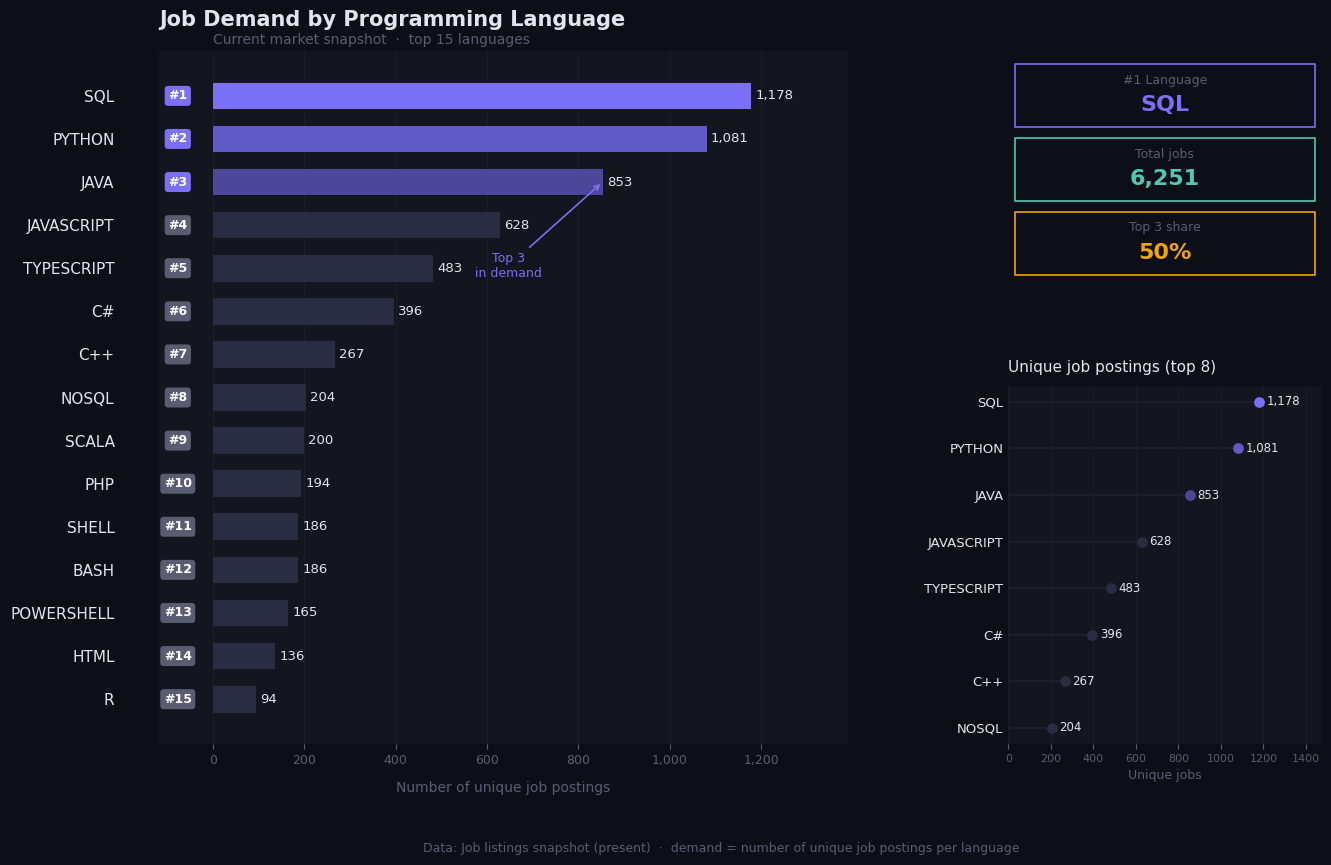

Saved -> step1_job_demand.png

  Rank  Language         Unique Jobs  Sources   Share%
  -------------------------------------------------------
  1     SQL                    1,178        3    18.8%
  2     PYTHON                 1,081        3    17.3%
  3     JAVA                     853        3    13.6%
  4     JAVASCRIPT               628        3    10.0%
  5     TYPESCRIPT               483        3     7.7%
  6     C#                       396        3     6.3%
  7     C++                      267        2     4.3%
  8     NOSQL                    204        1     3.3%
  9     SCALA                    200        2     3.2%
  10    PHP                      194        3     3.1%
  11    SHELL                    186        1     3.0%
  12    BASH                     186        1     3.0%
  13    POWERSHELL               165        1     2.6%
  14    HTML                     136        1     2.2%
  15    R                         94        2     1.5%


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── STEP 1: Aggregate ──────────────────────────────────────────────────
lang_demand = (
    df_master.groupby('prolangname')
    .agg(
        total_demand = ('jobid',      'nunique'),
        num_sources  = ('sourcename', 'nunique'),
    )
    .reset_index()
    .sort_values('total_demand', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

langs  = lang_demand['prolangname'].tolist()
demand = lang_demand['total_demand'].tolist()
n      = len(langs)

# ── STYLE ──────────────────────────────────────────────────────────────
BG     = '#0d0f18'
CARD   = '#13151f'
PURPLE = '#7C6FF7'
TEAL   = '#4EC9B0'
AMBER  = '#F0A500'
TEXT   = '#e2e4f0'
MUTED  = '#5a5d72'
GRID   = '#1e2030'

def bar_color(i):
    if i == 0: return '#7C6FF7'
    if i == 1: return '#6259c9'
    if i == 2: return '#4d4799'
    return '#2a2d42'

# ── FIGURE ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 9), facecolor=BG)

gs = fig.add_gridspec(2, 2,
                      width_ratios=[2.2, 1],
                      height_ratios=[1, 1.6],
                      hspace=0.38, wspace=0.32)

ax_main  = fig.add_subplot(gs[:, 0])
ax_cards = fig.add_subplot(gs[0, 1])
ax_dot   = fig.add_subplot(gs[1, 1])

for ax in [ax_main, ax_cards, ax_dot]:
    ax.set_facecolor(CARD)
    for spine in ax.spines.values():
        spine.set_visible(False)

# ── MAIN: Horizontal bar chart ─────────────────────────────────────────
y_pos  = np.arange(n)[::-1]
colors = [bar_color(i) for i in range(n)]

bars = ax_main.barh(y_pos, demand, color=colors,
                    height=0.62, zorder=2)

for i, (bar, val, lang) in enumerate(zip(bars, demand, langs)):
    rank     = i + 1
    badge_bg = PURPLE if rank <= 3 else MUTED
    y        = bar.get_y() + bar.get_height() / 2

    ax_main.text(-max(demand) * 0.065, y, f'#{rank}',
                 va='center', ha='center', fontsize=9,
                 color='white', fontweight='600',
                 bbox=dict(boxstyle='round,pad=0.28',
                           facecolor=badge_bg, edgecolor='none'))

    ax_main.text(val + max(demand) * 0.008, y,
                 f'{int(val):,}',
                 va='center', ha='left',
                 fontsize=9.5, color=TEXT)

ax_main.set_yticks(y_pos)
ax_main.set_yticklabels(langs, color=TEXT, fontsize=11)
ax_main.tick_params(axis='y', length=0, pad=32)
ax_main.tick_params(axis='x', colors=MUTED, labelsize=9)
ax_main.set_xlim(-max(demand) * 0.1, max(demand) * 1.18)
ax_main.xaxis.grid(True, color=GRID, linewidth=0.6, zorder=0)
ax_main.set_axisbelow(True)
ax_main.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{int(x):,}'))
ax_main.set_xlabel('Number of unique job postings',
                   color=MUTED, fontsize=10, labelpad=10)
ax_main.set_title('Job Demand by Programming Language',
                  color=TEXT, fontsize=15, fontweight='600',
                  pad=18, loc='left')
ax_main.text(0, n + 0.2,
             'Current market snapshot  ·  top 15 languages',
             color=MUTED, fontsize=10)

ax_main.annotate('Top 3\nin demand',
                 xy=(demand[2], y_pos[2]),
                 xytext=(demand[0] * 0.55, y_pos[2] - 2.2),
                 color=PURPLE, fontsize=9,
                 arrowprops=dict(arrowstyle='->', color=PURPLE, lw=1.2),
                 ha='center')

# ── TOP RIGHT: Summary metric cards ────────────────────────────────────
ax_cards.axis('off')

total_jobs  = int(lang_demand['total_demand'].sum())
top1_lang   = langs[0]
top1_val    = int(demand[0])
covered_pct = lang_demand.head(3)['total_demand'].sum() / total_jobs * 100

cards = [
    ('#1 Language', top1_lang,         PURPLE),
    ('Total jobs',  f'{total_jobs:,}', TEAL),
    ('Top 3 share', f'{covered_pct:.0f}%', AMBER),
]

for idx, (label, value, color) in enumerate(cards):
    yy = 0.78 - idx * 0.33
    ax_cards.add_patch(plt.Rectangle((0.02, yy - 0.12), 0.96, 0.28,
                                     transform=ax_cards.transAxes,
                                     facecolor=BG, edgecolor=color,
                                     linewidth=1.2, clip_on=False,
                                     zorder=2, joinstyle='round'))
    ax_cards.text(0.5, yy + 0.09, label,
                  transform=ax_cards.transAxes,
                  ha='center', va='center',
                  fontsize=9, color=MUTED)
    ax_cards.text(0.5, yy - 0.02, value,
                  transform=ax_cards.transAxes,
                  ha='center', va='center',
                  fontsize=16, color=color, fontweight='600')

# ── BOTTOM RIGHT: Lollipop chart ───────────────────────────────────────
top8    = lang_demand.head(8).reset_index(drop=True)
y8      = np.arange(len(top8))[::-1]
colors8 = [bar_color(i) for i in range(len(top8))]
vals8   = top8['total_demand'].tolist()

for i, (yi, val) in enumerate(zip(y8, vals8)):
    ax_dot.plot([0, val], [yi, yi],
                color=GRID, linewidth=1.2, zorder=1)
    ax_dot.scatter(val, yi, s=60, color=colors8[i],
                   zorder=3, linewidths=0)
    ax_dot.text(val + max(vals8) * 0.03, yi,
                f"{int(val):,}",
                va='center', fontsize=8.5, color=TEXT)

ax_dot.set_yticks(y8)
ax_dot.set_yticklabels(top8['prolangname'], color=TEXT, fontsize=9.5)
ax_dot.tick_params(axis='y', length=0)
ax_dot.tick_params(axis='x', colors=MUTED, labelsize=8)
ax_dot.set_xlim(0, max(vals8) * 1.25)
ax_dot.xaxis.grid(True, color=GRID, linewidth=0.5, zorder=0)
ax_dot.set_axisbelow(True)
ax_dot.set_title('Unique job postings (top 8)',
                 color=TEXT, fontsize=11, fontweight='500',
                 pad=10, loc='left')
ax_dot.set_xlabel('Unique jobs', color=MUTED, fontsize=9)

# ── FOOTER ─────────────────────────────────────────────────────────────
fig.text(0.5, -0.01,
         'Data: Job listings snapshot (present)  ·  '
         'demand = number of unique job postings per language',
         ha='center', color=MUTED, fontsize=9)

plt.savefig('step1_job_demand.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved -> step1_job_demand.png")

# ── Print summary table ────────────────────────────────────────────────
print(f"\n  {'Rank':<5} {'Language':<15} {'Unique Jobs':>12} "
      f"{'Sources':>8} {'Share%':>8}")
print(f"  {'-'*55}")
total = lang_demand['total_demand'].sum()
for i, row in lang_demand.iterrows():
    share = row['total_demand'] / total * 100
    print(f"  {i+1:<5} {row['prolangname']:<15} "
          f"{int(row['total_demand']):>12,} "
          f"{int(row['num_sources']):>8,} "
          f"{share:>7.1f}%")

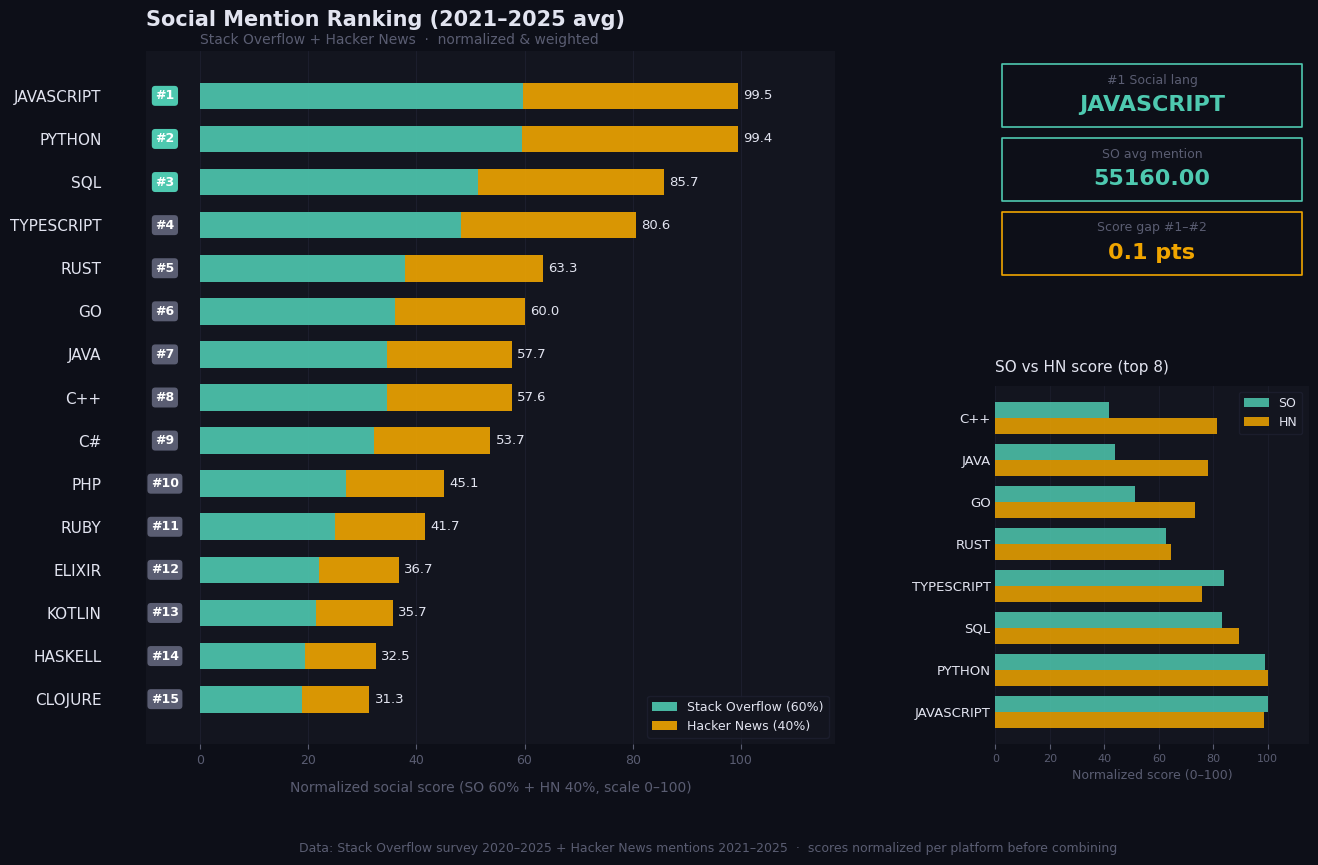

Saved → step2_social_mention.png

  Rank  Language           Avg SO    Avg HN  Social Score
  -------------------------------------------------------
  1     JAVASCRIPT      55160.000   247.600         99.49
  2     PYTHON          54584.000   250.800         99.37
  3     SQL             45876.000   224.400         85.69
  4     TYPESCRIPT      46219.600   190.000         80.58
  5     RUST            34472.800   162.000         63.33
  6     GO              28212.800   184.000         60.03
  7     JAVA            24240.000   196.200         57.66
  8     C++             22996.800   204.400         57.61
  9     C#              28524.400   142.200         53.71
  10    PHP             13123.600   193.200         45.09
  11    RUBY             7001.200   213.400         41.65
  12    ELIXIR           6102.400   188.800         36.75
  13    KOTLIN          16692.000   110.000         35.70
  14    HASKELL          4798.000   171.200         32.52
  15    CLOJURE          3036.800   17

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── STEP 2: Aggregate avg social mention ──────────────────────────────
# SO: 2020-2025 (6 ปี), HN: 2021-2025 (5 ปี)
# average ต่อ language แล้ว combine เป็น overall social score

so_cols = ['so_mension_2021','so_mension_2022',
           'so_mension_2023','so_mension_2024','so_mension_2025']
hn_cols = ['hn_mension_2021','hn_mension_2022','hn_mension_2023',
           'hn_mension_2024','hn_mension_2025']

lang_social = (
    df_master.groupby('prolangname')
    .agg(
        **{col: (col, 'first') for col in so_cols + hn_cols}
    )
    .reset_index()
)

lang_social['avg_so'] = lang_social[so_cols].mean(axis=1)
lang_social['avg_hn'] = lang_social[hn_cols].mean(axis=1)
lang_social['avg_so_norm'] = (
    lang_social['avg_so'] / lang_social['avg_so'].max() * 100
)
lang_social['avg_hn_norm'] = (
    lang_social['avg_hn'] / lang_social['avg_hn'].max() * 100
)
lang_social['social_score'] = (
    lang_social['avg_so_norm'] * 0.6 + lang_social['avg_hn_norm'] * 0.4
)

lang_social = (
    lang_social.sort_values('social_score', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

langs        = lang_social['prolangname'].tolist()
so_scores    = lang_social['avg_so_norm'].tolist()
hn_scores    = lang_social['avg_hn_norm'].tolist()
total_scores = lang_social['social_score'].tolist()
n            = len(langs)

# ── STYLE ──────────────────────────────────────────────────────────────
BG     = '#0d0f18'
CARD   = '#13151f'
SO_CLR = '#4EC9B0'    # teal = Stack Overflow
HN_CLR = '#F0A500'    # amber = Hacker News
TEXT   = '#e2e4f0'
MUTED  = '#5a5d72'
GRID   = '#1e2030'

def bar_color(i):
    if i == 0: return '#4EC9B0'
    if i == 1: return '#3aaa93'
    if i == 2: return '#2d8a76'
    return '#1e3d38'

# ── FIGURE ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 9), facecolor=BG)
gs  = fig.add_gridspec(2, 2,
                       width_ratios=[2.2, 1],
                       height_ratios=[1, 1.6],
                       hspace=0.38, wspace=0.32)

ax_main  = fig.add_subplot(gs[:, 0])
ax_cards = fig.add_subplot(gs[0, 1])
ax_split = fig.add_subplot(gs[1, 1])

for ax in [ax_main, ax_cards, ax_split]:
    ax.set_facecolor(CARD)
    for spine in ax.spines.values():
        spine.set_visible(False)

# ── MAIN: stacked bar SO + HN ──────────────────────────────────────────
y_pos = np.arange(n)[::-1]

# stacked: SO as base, HN on top (both normalized)
# แสดง breakdown ว่าแต่ละ score มาจาก platform ไหน
so_arr = np.array(so_scores)
hn_arr = np.array(hn_scores)

# scale ให้ total = social_score (weighted)
so_part = np.array(total_scores) * 0.6
hn_part = np.array(total_scores) * 0.4

bars_so = ax_main.barh(y_pos, so_part, color=SO_CLR,
                       height=0.62, alpha=0.9, zorder=2,
                       label='Stack Overflow (60%)')
bars_hn = ax_main.barh(y_pos, hn_part, left=so_part,
                       color=HN_CLR, height=0.62,
                       alpha=0.9, zorder=2,
                       label='Hacker News (40%)')

# rank badge + total label
for i, (val, lang) in enumerate(zip(total_scores, langs)):
    rank     = i + 1
    badge_bg = SO_CLR if rank <= 3 else MUTED
    y        = y_pos[i]

    ax_main.text(-max(total_scores) * 0.065, y, f'#{rank}',
                 va='center', ha='center', fontsize=9,
                 color='white', fontweight='600',
                 bbox=dict(boxstyle='round,pad=0.28',
                           facecolor=badge_bg, edgecolor='none'))

    ax_main.text(val + max(total_scores) * 0.01, y,
                 f'{val:.1f}',
                 va='center', ha='left',
                 fontsize=9.5, color=TEXT)

ax_main.set_yticks(y_pos)
ax_main.set_yticklabels(langs, color=TEXT, fontsize=11)
ax_main.tick_params(axis='y', length=0, pad=32)
ax_main.tick_params(axis='x', colors=MUTED, labelsize=9)
ax_main.set_xlim(-max(total_scores) * 0.1,
                  max(total_scores) * 1.18)
ax_main.xaxis.grid(True, color=GRID, linewidth=0.6, zorder=0)
ax_main.set_axisbelow(True)
ax_main.set_xlabel(
    'Normalized social score (SO 60% + HN 40%, scale 0–100)',
    color=MUTED, fontsize=10, labelpad=10)
ax_main.set_title('Social Mention Ranking (2021–2025 avg)',
                  color=TEXT, fontsize=15, fontweight='600',
                  pad=18, loc='left')
ax_main.text(0, n + 0.2,
             'Stack Overflow + Hacker News  ·  normalized & weighted',
             color=MUTED, fontsize=10)

leg = ax_main.legend(facecolor=CARD, edgecolor=GRID,
                     labelcolor=TEXT, fontsize=9,
                     loc='lower right')

# ── TOP RIGHT: metric cards ─────────────────────────────────────────────
ax_cards.axis('off')

top1        = langs[0]
avg_so_top1 = lang_social.loc[0, 'avg_so']
avg_hn_top1 = lang_social.loc[0, 'avg_hn']
gap         = total_scores[0] - total_scores[1]

cards = [
    ('#1 Social lang', top1,          SO_CLR),
    ('SO avg mention', f'{avg_so_top1:.2f}', '#4EC9B0'),
    ('Score gap #1–#2', f'{gap:.1f} pts',    HN_CLR),
]

for idx, (label, value, color) in enumerate(cards):
    yy = 0.78 - idx * 0.33
    ax_cards.add_patch(plt.Rectangle(
        (0.02, yy - 0.12), 0.96, 0.28,
        transform=ax_cards.transAxes,
        facecolor=BG, edgecolor=color, linewidth=1.2,
        clip_on=False, zorder=2, joinstyle='round'))
    ax_cards.text(0.5, yy + 0.09, label,
                  transform=ax_cards.transAxes,
                  ha='center', va='center',
                  fontsize=9, color=MUTED)
    ax_cards.text(0.5, yy - 0.02, value,
                  transform=ax_cards.transAxes,
                  ha='center', va='center',
                  fontsize=16, color=color, fontweight='600')

# ── BOTTOM RIGHT: SO vs HN side-by-side top 8 ──────────────────────────
top8     = lang_social.head(8)
y8       = np.arange(len(top8))
bar_w    = 0.38

so_norm8 = top8['avg_so_norm'].values
hn_norm8 = top8['avg_hn_norm'].values

ax_split.barh(y8 + bar_w/2, so_norm8, height=bar_w,
              color=SO_CLR, alpha=0.85, label='SO', zorder=2)
ax_split.barh(y8 - bar_w/2, hn_norm8, height=bar_w,
              color=HN_CLR, alpha=0.85, label='HN', zorder=2)

ax_split.set_yticks(y8)
ax_split.set_yticklabels(top8['prolangname'], color=TEXT, fontsize=9.5)
ax_split.tick_params(axis='y', length=0)
ax_split.tick_params(axis='x', colors=MUTED, labelsize=8)
ax_split.set_xlim(0, 115)
ax_split.xaxis.grid(True, color=GRID, linewidth=0.5, zorder=0)
ax_split.set_axisbelow(True)
ax_split.set_title('SO vs HN score (top 8)',
                   color=TEXT, fontsize=11, fontweight='500',
                   pad=10, loc='left')
ax_split.set_xlabel('Normalized score (0–100)',
                    color=MUTED, fontsize=9)
leg2 = ax_split.legend(facecolor=CARD, edgecolor=GRID,
                        labelcolor=TEXT, fontsize=9)

# ── FOOTER ─────────────────────────────────────────────────────────────
fig.text(0.5, -0.01,
         'Data: Stack Overflow survey 2020–2025 + Hacker News mentions 2021–2025  ·  '
         'scores normalized per platform before combining',
         ha='center', color=MUTED, fontsize=9)

plt.savefig('step2_social_mention.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved → step2_social_mention.png")

# ── Print summary table ────────────────────────────────────────────────
print(f"\n  {'Rank':<5} {'Language':<15} {'Avg SO':>9} "
      f"{'Avg HN':>9} {'Social Score':>13}")
print(f"  {'-'*55}")
for i, row in lang_social.iterrows():
    print(f"  {i+1:<5} {row['prolangname']:<15} "
          f"{row['avg_so']:>9.3f} "
          f"{row['avg_hn']:>9.3f} "
          f"{row['social_score']:>13.2f}")

soc_threshold: 30
dem_threshold_star: 5
dem_threshold_gem: 2.4
    prolangname  social_score  demand_norm     quadrant
19       KOTLIN     35.700495     2.886248    Buzz only
30         RUST     63.334928     2.801358    Buzz only
7       CLOJURE     31.309643     0.084890    Buzz only
29         RUBY     41.650606     2.886248    Buzz only
11       ELIXIR     36.749496     0.169779    Buzz only
15      HASKELL     32.523624     0.169779    Buzz only
37        SWIFT     28.195269     3.565365   Hidden gem
35        SHELL     14.786802    15.789474   Hidden gem
33       SCHEME     28.835726     4.923599   Hidden gem
32        SCALA     14.749842    16.977929   Hidden gem
31          SAS      0.318927     3.904924   Hidden gem
28            R      6.002284     7.979626   Hidden gem
26   POWERSHELL     10.024220    14.006791   Hidden gem
24         PERL     12.946219     5.517827   Hidden gem
22        NOSQL      0.000000    17.317487   Hidden gem
21      NODE.JS     10.485859     3.48047

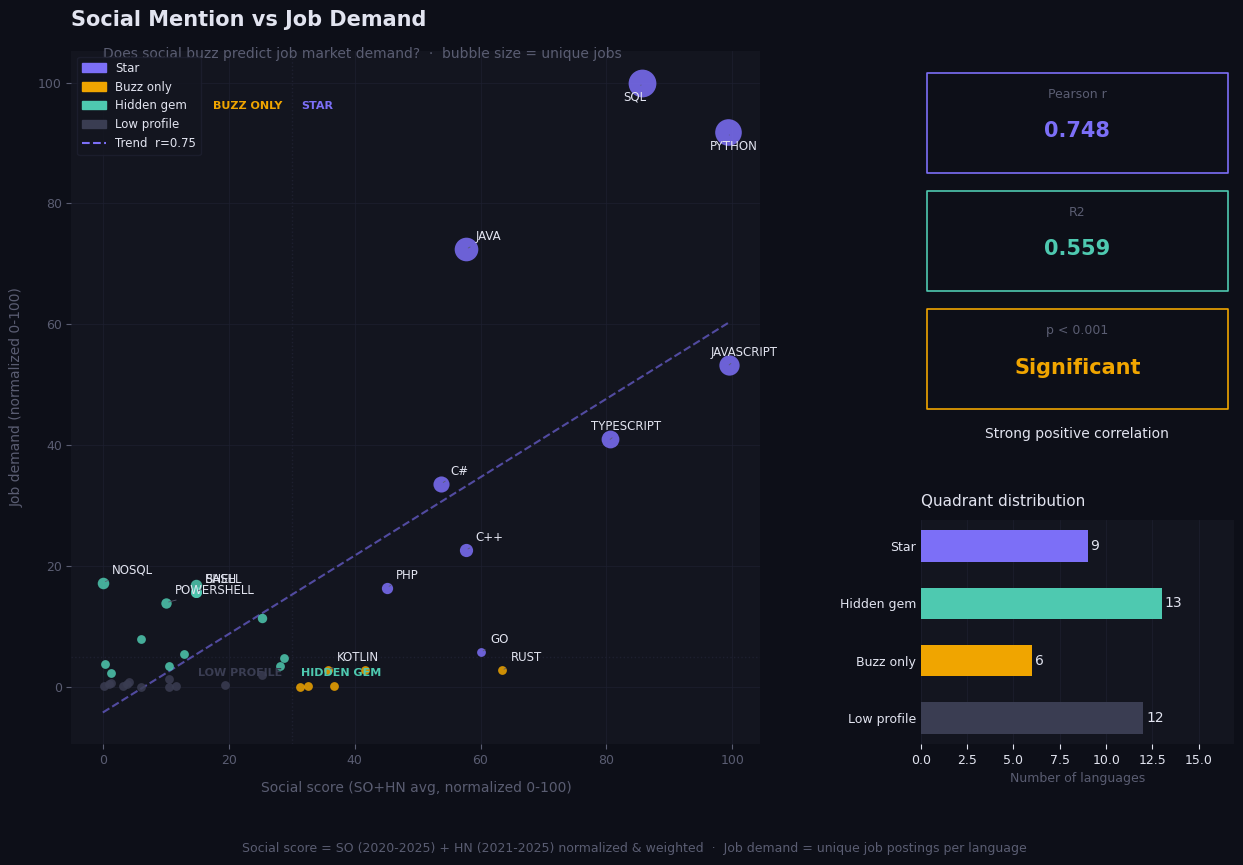

Saved -> step3_scatter.png

  Language          Social   Demand Quadrant      
  --------------------------------------------------
  KOTLIN              35.7      2.9  Buzz only
  RUST                63.3      2.8  Buzz only
  CLOJURE             31.3      0.1  Buzz only
  RUBY                41.7      2.9  Buzz only
  ELIXIR              36.7      0.2  Buzz only
  HASKELL             32.5      0.2  Buzz only
  SWIFT               28.2      3.6  Hidden gem
  SHELL               14.8     15.8  Hidden gem
  SCHEME              28.8      4.9  Hidden gem
  SCALA               14.7     17.0  Hidden gem
  SAS                  0.3      3.9  Hidden gem
  R                    6.0      8.0  Hidden gem
  POWERSHELL          10.0     14.0  Hidden gem
  PERL                12.9      5.5  Hidden gem
  NOSQL                0.0     17.3  Hidden gem
  NODE.JS             10.5      3.5  Hidden gem
  VB.NET               1.3      2.5  Hidden gem
  BASH                14.8     15.8  Hidden gem
  HTML    

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy import stats

# ── AGGREGATE ─────────────────────────────────────────────────────────
so_cols = ['so_mension_2021','so_mension_2022',
           'so_mension_2023','so_mension_2024','so_mension_2025']
hn_cols = ['hn_mension_2021','hn_mension_2022',
           'hn_mension_2023','hn_mension_2024','hn_mension_2025']

lang_agg = (
    df_master.groupby('prolangname')
    .agg(
        total_demand = ('jobid', 'nunique'),
        **{col: (col, 'first') for col in so_cols + hn_cols}
    )
    .reset_index()
)

lang_agg['avg_so']       = lang_agg[so_cols].mean(axis=1)
lang_agg['avg_hn']       = lang_agg[hn_cols].mean(axis=1)
lang_agg['avg_so_norm']  = lang_agg['avg_so'] / lang_agg['avg_so'].max() * 100
lang_agg['avg_hn_norm']  = lang_agg['avg_hn'] / lang_agg['avg_hn'].max() * 100
lang_agg['social_score'] = (lang_agg['avg_so_norm'] * 0.6 +
                             lang_agg['avg_hn_norm'] * 0.4)
lang_agg['demand_norm']  = (lang_agg['total_demand'] /
                             lang_agg['total_demand'].max() * 100)

# ── QUADRANT ───────────────────────────────────────────────────────────
soc_threshold      = 30
dem_threshold_star = 5
dem_threshold_gem  = 2.4

def quadrant(row):
    h_soc      = row['social_score'] >= soc_threshold
    h_dem_star = row['demand_norm']  >= dem_threshold_star
    h_dem_gem  = row['demand_norm']  >= dem_threshold_gem
    if h_soc and h_dem_star:   return 'Star'
    if h_soc:                  return 'Buzz only'
    if h_dem_gem:              return 'Hidden gem'
    return 'Low profile'

lang_agg['quadrant'] = lang_agg.apply(quadrant, axis=1)

print("soc_threshold:", soc_threshold)
print("dem_threshold_star:", dem_threshold_star)
print("dem_threshold_gem:", dem_threshold_gem)
print(lang_agg[['prolangname','social_score','demand_norm','quadrant']]
      .sort_values('quadrant'))

# ── CORRELATION ────────────────────────────────────────────────────────
r, p = stats.pearsonr(lang_agg['social_score'], lang_agg['demand_norm'])
slope, intercept, *_ = stats.linregress(lang_agg['social_score'],
                                         lang_agg['demand_norm'])

# ── STYLE ──────────────────────────────────────────────────────────────
BG    = '#0d0f18'
CARD  = '#13151f'
TEXT  = '#e2e4f0'
MUTED = '#5a5d72'
GRID  = '#1e2030'

Q_COLORS = {
    'Star':        '#7C6FF7',
    'Buzz only':   '#F0A500',
    'Hidden gem':  '#4EC9B0',
    'Low profile': '#3a3d52',
}

LABEL_LANGS = ['PYTHON','SQL','JAVASCRIPT','JAVA','TYPESCRIPT',
               'RUST','GO','C#','C++','KOTLIN','PHP','SHELL',
               'BASH','NOSQL','POWERSHELL']

# ── FIGURE ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 9), facecolor=BG)
gs  = fig.add_gridspec(2, 2,
                       width_ratios=[2.2, 1],
                       height_ratios=[1.6, 1],
                       hspace=0.38, wspace=0.32)

ax_main  = fig.add_subplot(gs[:, 0])
ax_stats = fig.add_subplot(gs[0, 1])
ax_quad  = fig.add_subplot(gs[1, 1])

for ax in [ax_main, ax_stats, ax_quad]:
    ax.set_facecolor(CARD)
    for spine in ax.spines.values():
        spine.set_visible(False)

# ── SCATTER ────────────────────────────────────────────────────────────
for _, row in lang_agg.iterrows():
    q     = row['quadrant']
    color = Q_COLORS[q]
    size  = max(40, row['total_demand'] / lang_agg['total_demand'].max() * 400)

    ax_main.scatter(row['social_score'], row['demand_norm'],
                    s=size, color=color, alpha=0.85,
                    zorder=3, linewidths=0)

    if row['prolangname'] in LABEL_LANGS:
        x_off = 1.5
        y_off = 1.5
        if row['social_score'] > 80: x_off = -3
        if row['demand_norm']  > 80: y_off = -3

        ax_main.annotate(
            row['prolangname'],
            xy=(row['social_score'], row['demand_norm']),
            xytext=(row['social_score'] + x_off,
                    row['demand_norm']  + y_off),
            fontsize=8.5, color=TEXT, zorder=4,
            arrowprops=dict(arrowstyle='-', color=MUTED, lw=0.6)
        )

# regression line
x_line = np.linspace(lang_agg['social_score'].min(),
                      lang_agg['social_score'].max(), 100)
y_line = slope * x_line + intercept
ax_main.plot(x_line, y_line, color='#7C6FF7',
             linewidth=1.5, linestyle='--', alpha=0.6,
             zorder=2, label=f'Trend line  r={r:.2f}')

# quadrant dividers
ax_main.axvline(soc_threshold,      color=GRID, linewidth=1, linestyle=':', zorder=1)
ax_main.axhline(dem_threshold_star, color=GRID, linewidth=1, linestyle=':', zorder=1)

pad    = 1.5
d_max  = lang_agg['demand_norm'].max()
ax_main.text(soc_threshold + pad, d_max * 0.97,
             'STAR', color=Q_COLORS['Star'],
             fontsize=8, fontweight='600', ha='left', va='top')
ax_main.text(soc_threshold - pad, d_max * 0.97,
             'BUZZ ONLY', color=Q_COLORS['Buzz only'],
             fontsize=8, fontweight='600', ha='right', va='top')
ax_main.text(soc_threshold + pad, dem_threshold_star * 0.3,
             'HIDDEN GEM', color=Q_COLORS['Hidden gem'],
             fontsize=8, fontweight='600', ha='left', va='bottom')
ax_main.text(soc_threshold - pad, dem_threshold_star * 0.3,
             'LOW PROFILE', color=Q_COLORS['Low profile'],
             fontsize=8, fontweight='600', ha='right', va='bottom')

ax_main.set_xlabel('Social score (SO+HN avg, normalized 0-100)',
                   color=MUTED, fontsize=10, labelpad=10)
ax_main.set_ylabel('Job demand (normalized 0-100)',
                   color=MUTED, fontsize=10, labelpad=10)
ax_main.set_title('Social Mention vs Job Demand',
                  color=TEXT, fontsize=15, fontweight='600',
                  pad=18, loc='left')
ax_main.text(0, d_max * 1.04,
             'Does social buzz predict job market demand?  ·  bubble size = unique jobs',
             color=MUTED, fontsize=10)
ax_main.tick_params(colors=MUTED, labelsize=9)
ax_main.xaxis.grid(True, color=GRID, linewidth=0.5, zorder=0)
ax_main.yaxis.grid(True, color=GRID, linewidth=0.5, zorder=0)
ax_main.set_axisbelow(True)

q_patches  = [mpatches.Patch(color=v, label=k) for k, v in Q_COLORS.items()]
trend_line = plt.Line2D([0], [0], color='#7C6FF7', linewidth=1.5,
                         linestyle='--', label=f'Trend  r={r:.2f}')
ax_main.legend(handles=q_patches + [trend_line],
               facecolor=CARD, edgecolor=GRID,
               labelcolor=TEXT, fontsize=8.5, loc='upper left')

# ── STATS CARDS ────────────────────────────────────────────────────────
ax_stats.axis('off')
p_label   = 'p < 0.001' if p < 0.001 else f'p = {p:.3f}'
sig       = 'Significant' if p < 0.05 else 'Not significant'
interp    = 'Strong' if abs(r) > 0.7 else 'Moderate' if abs(r) > 0.4 else 'Weak'
direction = 'positive' if r > 0 else 'negative'

for idx, (label, value, color) in enumerate([
    ('Pearson r', f'{r:.3f}',    '#7C6FF7'),
    ('R2',        f'{r**2:.3f}', '#4EC9B0'),
    (p_label,     sig,           '#F0A500'),
]):
    yy = 0.78 - idx * 0.33
    ax_stats.add_patch(plt.Rectangle(
        (0.02, yy - 0.12), 0.96, 0.28,
        transform=ax_stats.transAxes,
        facecolor=BG, edgecolor=color, linewidth=1.2,
        clip_on=False, zorder=2, joinstyle='round'))
    ax_stats.text(0.5, yy + 0.09, label, transform=ax_stats.transAxes,
                  ha='center', fontsize=9, color=MUTED)
    ax_stats.text(0.5, yy - 0.02, value, transform=ax_stats.transAxes,
                  ha='center', fontsize=15, color=color, fontweight='600')

ax_stats.text(0.5, -0.08, f'{interp} {direction} correlation',
              transform=ax_stats.transAxes,
              ha='center', fontsize=10, color=TEXT)

# ── QUADRANT COUNT BAR ─────────────────────────────────────────────────
q_counts = lang_agg['quadrant'].value_counts()
q_order  = ['Star', 'Hidden gem', 'Buzz only', 'Low profile']
counts   = [q_counts.get(q, 0) for q in q_order]
colors_q = [Q_COLORS[q] for q in q_order]

bars = ax_quad.barh(q_order[::-1], counts[::-1],
                    color=colors_q[::-1], height=0.55, zorder=2)

for bar, val in zip(bars, counts[::-1]):
    ax_quad.text(val + 0.15, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=10, color=TEXT)

ax_quad.set_xlabel('Number of languages', color=MUTED, fontsize=9)
ax_quad.set_title('Quadrant distribution', color=TEXT,
                  fontsize=11, fontweight='500', pad=10, loc='left')
ax_quad.tick_params(colors=TEXT, labelsize=9)
ax_quad.tick_params(axis='y', length=0)
ax_quad.set_xlim(0, max(counts) * 1.3)
ax_quad.xaxis.grid(True, color=GRID, linewidth=0.5, zorder=0)
ax_quad.set_axisbelow(True)

# ── FOOTER ─────────────────────────────────────────────────────────────
fig.text(0.5, -0.01,
         'Social score = SO (2020-2025) + HN (2021-2025) normalized & weighted  ·  '
         'Job demand = unique job postings per language',
         ha='center', color=MUTED, fontsize=9)

plt.savefig('step3_scatter.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved -> step3_scatter.png")

print(f"\n  {'Language':<15} {'Social':>8} {'Demand':>8} {'Quadrant':<14}")
print(f"  {'-'*50}")
for _, row in lang_agg.sort_values('quadrant').iterrows():
    print(f"  {row['prolangname']:<15} "
          f"{row['social_score']:>8.1f} "
          f"{row['demand_norm']:>8.1f}  "
          f"{row['quadrant']}")

print(lang_agg['demand_norm'].describe())
print(lang_agg['demand_norm'].quantile([0.25, 0.50, 0.75]))


  Language        Social Rank Demand Rank   Diff  Verdict
  -----------------------------------------------------------------
  JAVA                      7           3     -4  None
  HTML                     18          14     -4  None
  C#                        9           6     -3  None
  SQL                       3           1     -2  None
  C++                       8           7     -1  None
  PHP                      10          10      0  None
  PYTHON                    2           2      0  None
  TYPESCRIPT                4           5     +1  None
  SCHEME                   16          18     +2  None
  JAVASCRIPT                1           4     +3  None
  SWIFT                    17          20     +3  None
  CSS                      18          26     +8  None
  KOTLIN                   13          22     +9  None
  GO                        6          16    +10  None
  RUBY                     11          22    +11  None
  DART                     20          32    +12

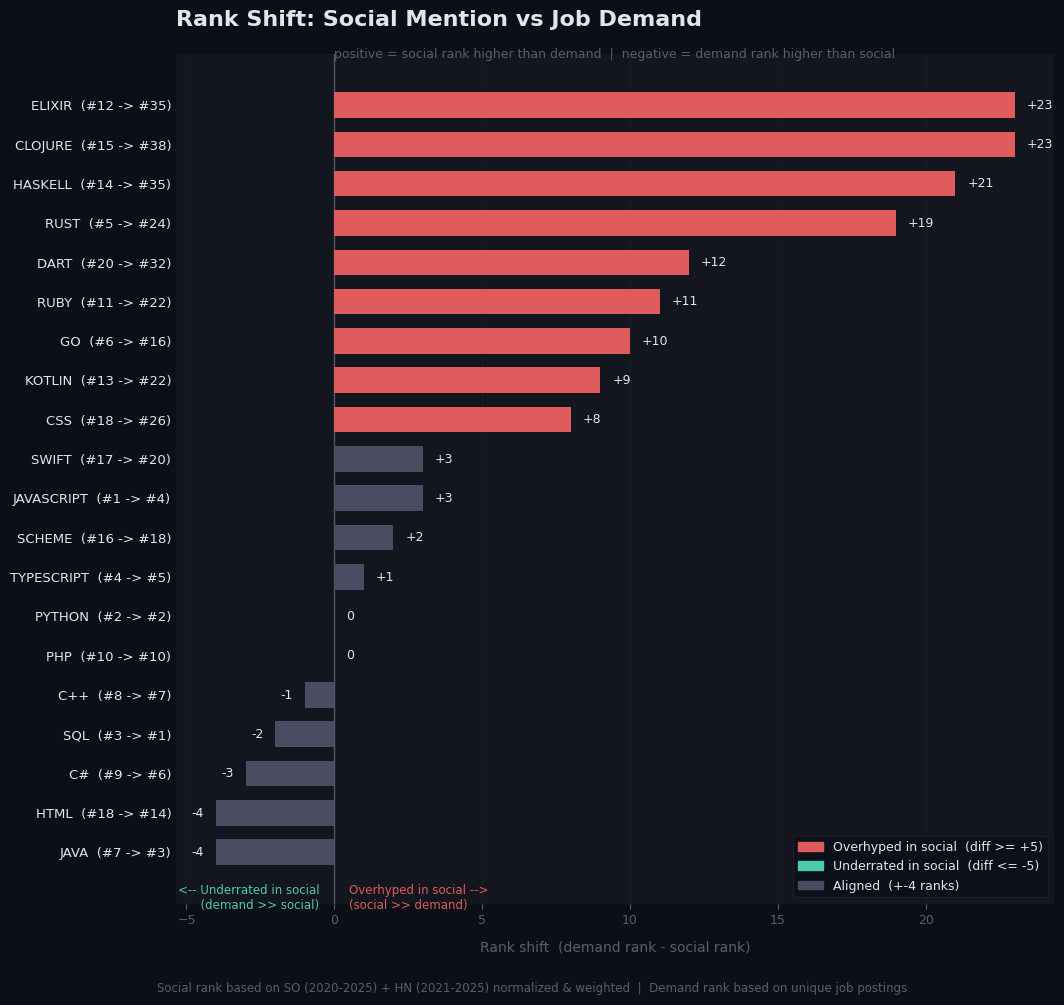


Saved -> step4b_rank_shift.png


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── AGGREGATE ──────────────────────────────────────────────────────────
so_cols = ['so_mension_2021','so_mension_2022',
           'so_mension_2023','so_mension_2024','so_mension_2025']
hn_cols = ['hn_mension_2021','hn_mension_2022','hn_mension_2023',
           'hn_mension_2024','hn_mension_2025']

lang_agg = (
    df_master.groupby('prolangname')
    .agg(
        total_demand = ('jobid', 'nunique'),        # ← fixed
        **{col: (col, 'first') for col in so_cols + hn_cols}
    )
    .reset_index()
)

lang_agg['avg_so']       = lang_agg[so_cols].mean(axis=1)
lang_agg['avg_hn']       = lang_agg[hn_cols].mean(axis=1)
lang_agg['avg_so_norm']  = lang_agg['avg_so'] / lang_agg['avg_so'].max() * 100
lang_agg['avg_hn_norm']  = lang_agg['avg_hn'] / lang_agg['avg_hn'].max() * 100
lang_agg['social_score'] = (lang_agg['avg_so_norm'] * 0.6 +
                             lang_agg['avg_hn_norm'] * 0.4)

lang_agg['rank_social'] = lang_agg['social_score'].rank(
    ascending=False, method='min').astype(int)
lang_agg['rank_demand'] = lang_agg['total_demand'].rank(
    ascending=False, method='min').astype(int)
lang_agg['rank_diff']   = lang_agg['rank_demand'] - lang_agg['rank_social']

top20 = (lang_agg[lang_agg['rank_social'] <= 20]
         .sort_values('rank_social')
         .reset_index(drop=True))

# ── STYLE ──────────────────────────────────────────────────────────────
BG    = '#0d0f18'
CARD  = '#13151f'
TEXT  = '#e2e4f0'
MUTED = '#5a5d72'
GRID  = '#1e2030'
TEAL  = '#4EC9B0'
RED   = '#E05C5C'

def bar_color(diff):
    if   diff >=  5: return RED
    elif diff <= -5: return TEAL
    else:            return '#4a4d62'

def verdict(diff):                      # ← fixed
    if   diff >=  5: return 
    elif diff <= -5: return 
    else:            return 

bar_df = top20.sort_values('rank_diff', ascending=True).reset_index(drop=True)

# ── FIGURE ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 10), facecolor=BG)
ax.set_facecolor(CARD)
for spine in ax.spines.values():
    spine.set_visible(False)

n      = len(bar_df)
y_pos  = np.arange(n)
colors = [bar_color(d) for d in bar_df['rank_diff']]

bars = ax.barh(y_pos, bar_df['rank_diff'],
               color=colors, height=0.65, zorder=2)

for i, (bar, row) in enumerate(zip(bars, bar_df.itertuples())):
    diff  = int(row.rank_diff)
    sign  = f"+{diff}" if diff > 0 else str(diff)
    v     = verdict(diff)
    y_mid = bar.get_y() + bar.get_height() / 2

    if diff >= 0:
        ax.text(diff + 0.4, y_mid, sign,
                va="center", ha="left", fontsize=9,
                color=TEXT, fontweight="500")
        ax.text(diff + 2.2, y_mid, v,
                va="center", ha="left", fontsize=8.5,
                color=MUTED)
    else:
        ax.text(diff - 0.4, y_mid, sign,
                va="center", ha="right", fontsize=9,
                color=TEXT, fontweight="500")
        ax.text(diff - 2.2, y_mid, v,
                va="center", ha="right", fontsize=8.5,
                color=MUTED)

ax.axvline(0, color=TEXT, linewidth=1, alpha=0.3, zorder=1)

ax.text(-0.5, -0.8, '<-- Underrated in social\n  (demand >> social)',
        ha='right', fontsize=8.5, color=TEAL, va='top')
ax.text(0.5,  -0.8, 'Overhyped in social -->\n(social >> demand)',
        ha='left',  fontsize=8.5, color=RED,  va='top')

ax.set_yticks(y_pos)
ax.set_yticklabels(
    [f'{row.prolangname}  (#{int(row.rank_social)} -> #{int(row.rank_demand)})'
     for row in bar_df.itertuples()],
    color=TEXT, fontsize=9.5)
ax.tick_params(axis='y', length=0)
ax.tick_params(axis='x', colors=MUTED, labelsize=9)
ax.xaxis.grid(True, color=GRID, linewidth=0.5, zorder=0)
ax.set_axisbelow(True)
ax.set_xlabel('Rank shift  (demand rank - social rank)',
              color=MUTED, fontsize=10, labelpad=10)
ax.set_title('Rank Shift: Social Mention vs Job Demand',
             color=TEXT, fontsize=16, fontweight='700', pad=20, loc='left')
ax.text(0, n + 0.2,
        'positive = social rank higher than demand  |  '
        'negative = demand rank higher than social',
        color=MUTED, fontsize=9)

patches = [
    mpatches.Patch(color=RED,       label='Overhyped in social  (diff >= +5)'),
    mpatches.Patch(color=TEAL,      label='Underrated in social  (diff <= -5)'),
    mpatches.Patch(color='#4a4d62', label='Aligned  (+-4 ranks)'),
]
ax.legend(handles=patches, facecolor=BG, edgecolor=GRID,
          labelcolor=TEXT, fontsize=9, loc='lower right')

fig.text(0.5, -0.01,
         'Social rank based on SO (2020-2025) + HN (2021-2025) normalized & weighted  |  '
         'Demand rank based on unique job postings',
         ha='center', color=MUTED, fontsize=8.5)

# ── Print summary ──────────────────────────────────────────────────────
print(f"\n  {'Language':<15} {'Social Rank':>11} {'Demand Rank':>11} "
      f"{'Diff':>6}  {'Verdict'}")
print(f"  {'-'*65}")
for row in bar_df.itertuples():
    diff = int(row.rank_diff)
    sign = f'+{diff}' if diff > 0 else str(diff)
    print(f"  {row.prolangname:<15} {int(row.rank_social):>11} "
          f"{int(row.rank_demand):>11} {sign:>6}  {verdict(diff)}")

plt.tight_layout(pad=2)
plt.savefig('step4b_rank_shift.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print("\nSaved -> step4b_rank_shift.png")

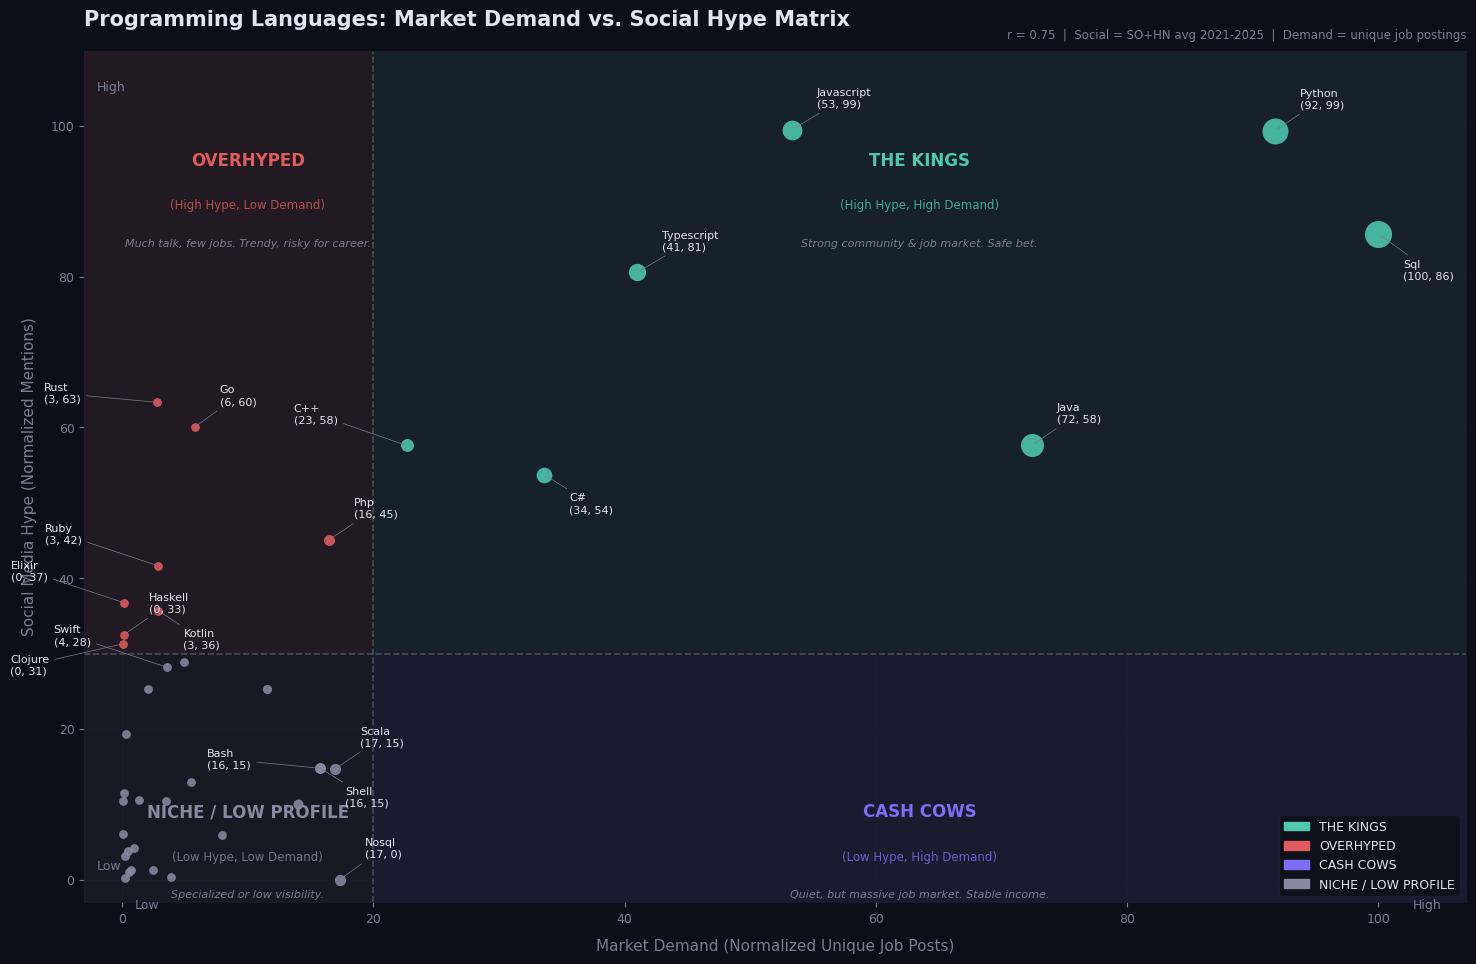

Saved -> step3_matrix.png

  Language          Social   Demand  Quadrant
  ----------------------------------------------------
  NOSQL                0.0     17.3  NICHE
  SCALA               14.7     17.0  NICHE
  BASH                14.8     15.8  NICHE
  SHELL               14.8     15.8  NICHE
  POWERSHELL          10.0     14.0  NICHE
  HTML                25.3     11.5  NICHE
  R                    6.0      8.0  NICHE
  PERL                12.9      5.5  NICHE
  SCHEME              28.8      4.9  NICHE
  SAS                  0.3      3.9  NICHE
  SWIFT               28.2      3.6  NICHE
  NODE.JS             10.5      3.5  NICHE
  VB.NET               1.3      2.5  NICHE
  CSS                 25.3      2.0  NICHE
  ADA                 10.5      1.4  NICHE
  MATLAB               4.2      0.9  NICHE
  SCRATCH              1.3      0.7  NICHE
  APEX                 1.0      0.6  NICHE
  OBJECTIVE-C          3.8      0.5  NICHE
  DART                19.4      0.3  NICHE
  ABAP      

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import numpy as np
from scipy import stats

# ── AGGREGATE ──────────────────────────────────────────────────────────
so_cols = ['so_mension_2021','so_mension_2022',
           'so_mension_2023','so_mension_2024','so_mension_2025']
hn_cols = ['hn_mension_2021','hn_mension_2022','hn_mension_2023',
           'hn_mension_2024','hn_mension_2025']

lang_agg = (
    df_master.groupby('prolangname')
    .agg(
        total_demand = ('jobid', 'nunique'),        # ← fixed
        **{col: (col, 'first') for col in so_cols + hn_cols}
    )
    .reset_index()
)

lang_agg['avg_so']       = lang_agg[so_cols].mean(axis=1)
lang_agg['avg_hn']       = lang_agg[hn_cols].mean(axis=1)
lang_agg['avg_so_norm']  = lang_agg['avg_so'] / lang_agg['avg_so'].max() * 100
lang_agg['avg_hn_norm']  = lang_agg['avg_hn'] / lang_agg['avg_hn'].max() * 100
lang_agg['social_score'] = (lang_agg['avg_so_norm'] * 0.6 +
                             lang_agg['avg_hn_norm'] * 0.4)
lang_agg['demand_norm']  = (lang_agg['total_demand'] /
                             lang_agg['total_demand'].max() * 100)

# ── THRESHOLDS ─────────────────────────────────────────────────────────
SOC_T = 30
DEM_T = 20

def quadrant(row):
    h_soc = row['social_score'] >= SOC_T
    h_dem = row['demand_norm']  >= DEM_T
    if h_soc and h_dem:      return 'THE KINGS'
    if h_soc and not h_dem:  return 'OVERHYPED'
    if not h_soc and h_dem:  return 'CASH COWS'
    return 'NICHE'

lang_agg['quadrant'] = lang_agg.apply(quadrant, axis=1)

# ── LABEL OFFSETS ──────────────────────────────────────────────────────
LABEL_OFFSETS = {
    'PYTHON':     (  2,   3),
    'SQL':        (  2,  -6),
    'JAVA':       (  2,   3),
    'JAVASCRIPT': (  2,   3),
    'TYPESCRIPT': (  2,   3),
    'GO':         (  2,   3),
    'RUST':       ( -9,   0),
    'C++':        ( -9,   3),
    'C#':         (  2,  -5),
    'PHP':        (  2,   3),
    'RUBY':       ( -9,   3),
    'KOTLIN':     (  2,  -5),
    'ELIXIR':     ( -9,   3),
    'HASKELL':    (  2,   3),
    'CLOJURE':    ( -9,  -4),
    'SWIFT':      ( -9,   3),
    'SCALA':      (  2,   3),
    'BASH':       ( -9,   0),
    'SHELL':      (  2,  -5),
    'NOSQL':      (  2,   3),
}

# ── STYLE ──────────────────────────────────────────────────────────────
BG    = '#0d0f18'
CARD  = '#13151f'
TEXT  = '#e2e4f0'
MUTED = '#7a7d92'
GRID  = '#1e2030'

Q_STYLE = {
    'THE KINGS': {'color':'#4EC9B0', 'label':'THE KINGS',
                  'sub':'(High Hype, High Demand)',
                  'desc':'Strong community & job market. Safe bet.',
                  'title_clr':'#4EC9B0'},
    'OVERHYPED': {'color':'#E05C5C', 'label':'OVERHYPED',
                  'sub':'(High Hype, Low Demand)',
                  'desc':'Much talk, few jobs. Trendy, risky for career.',
                  'title_clr':'#E05C5C'},
    'CASH COWS': {'color':'#7C6FF7', 'label':'CASH COWS',
                  'sub':'(Low Hype, High Demand)',
                  'desc':'Quiet, but massive job market. Stable income.',
                  'title_clr':'#7C6FF7'},
    'NICHE':     {'color':'#888aA0', 'label':'NICHE / LOW PROFILE',
                  'sub':'(Low Hype, Low Demand)',
                  'desc':'Specialized or low visibility.',
                  'title_clr':'#888aA0'},
}

# ── FIGURE ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 10), facecolor=BG)
ax.set_facecolor(CARD)
for spine in ax.spines.values():
    spine.set_color(GRID)
    spine.set_linewidth(0.5)

ax.set_xlim(-3, 107)
ax.set_ylim(-3, 110)

# ── QUADRANT BACKGROUNDS ───────────────────────────────────────────────
ax.add_patch(Rectangle((-3, SOC_T),    DEM_T+3,   110-SOC_T,
             facecolor='#E05C5C', alpha=0.07, zorder=0))
ax.add_patch(Rectangle((DEM_T, SOC_T), 110-DEM_T, 110-SOC_T,
             facecolor='#4EC9B0', alpha=0.07, zorder=0))
ax.add_patch(Rectangle((-3, -3),       DEM_T+3,   SOC_T+3,
             facecolor='#888888', alpha=0.04, zorder=0))
ax.add_patch(Rectangle((DEM_T, -3),    110-DEM_T, SOC_T+3,
             facecolor='#7C6FF7', alpha=0.07, zorder=0))

# ── DIVIDER LINES ──────────────────────────────────────────────────────
ax.axhline(SOC_T, color=MUTED, linewidth=1.2, linestyle='--', alpha=0.5, zorder=1)
ax.axvline(DEM_T, color=MUTED, linewidth=1.2, linestyle='--', alpha=0.5, zorder=1)

# ── QUADRANT LABELS ────────────────────────────────────────────────────
mid_left  = DEM_T / 2
mid_right = DEM_T + (107 - DEM_T) / 2
top_y     = SOC_T + (107 - SOC_T) * 0.85
bot_y     = SOC_T * 0.30

for q, qx, qy in [
    ('OVERHYPED', mid_left,  top_y),
    ('THE KINGS', mid_right, top_y),
    ('NICHE',     mid_left,  bot_y),
    ('CASH COWS', mid_right, bot_y),
]:
    s = Q_STYLE[q]
    ax.text(qx, qy,      s['label'],
            ha='center', va='center', fontsize=12,
            color=s['title_clr'], fontweight='700', zorder=5)
    ax.text(qx, qy - 6,  s['sub'],
            ha='center', va='center', fontsize=8.5,
            color=s['title_clr'], alpha=0.8, zorder=5)
    ax.text(qx, qy - 11, s['desc'],
            ha='center', va='center', fontsize=8,
            color=MUTED, style='italic', zorder=5)

# ── SCATTER ────────────────────────────────────────────────────────────
for _, row in lang_agg.iterrows():
    q     = row['quadrant']
    color = Q_STYLE[q]['color']
    size  = max(40, row['total_demand'] / lang_agg['total_demand'].max() * 380)  # ← fixed
    x     = row['demand_norm']
    y     = row['social_score']

    ax.scatter(x, y, s=size, color=color,
               alpha=0.88, zorder=4, linewidths=0)

    lang = row['prolangname']
    if lang in LABEL_OFFSETS:
        xo, yo = LABEL_OFFSETS[lang]
        ax.annotate(
            f"{lang.title()}\n({x:.0f}, {y:.0f})",
            xy=(x, y), xytext=(x + xo, y + yo),
            fontsize=8, color=TEXT, zorder=6,
            arrowprops=dict(arrowstyle='-', color=MUTED, lw=0.5)
        )

# ── CORRELATION ────────────────────────────────────────────────────────
r, p = stats.pearsonr(lang_agg['demand_norm'], lang_agg['social_score'])

# ── AXIS ───────────────────────────────────────────────────────────────
ax.set_xlabel('Market Demand (Normalized Unique Job Posts)',
              color=MUTED, fontsize=11, labelpad=10)
ax.set_ylabel('Social Media Hype (Normalized Mentions)',
              color=MUTED, fontsize=11, labelpad=10)
ax.tick_params(colors=MUTED, labelsize=9)
ax.xaxis.grid(True, color=GRID, linewidth=0.4, zorder=0)
ax.yaxis.grid(True, color=GRID, linewidth=0.4, zorder=0)
ax.set_axisbelow(True)

ax.text(1,   -2.5, 'Low',  color=MUTED, fontsize=9, ha='left',  va='top')
ax.text(105, -2.5, 'High', color=MUTED, fontsize=9, ha='right', va='top')
ax.text(-2,  106,  'High', color=MUTED, fontsize=9, ha='left',  va='top')
ax.text(-2,    1,  'Low',  color=MUTED, fontsize=9, ha='left',  va='bottom')

# ── TITLE ──────────────────────────────────────────────────────────────
ax.set_title('Programming Languages: Market Demand vs. Social Hype Matrix',
             color=TEXT, fontsize=15, fontweight='700', pad=18, loc='left')
ax.text(1, 1.01,
        f'r = {r:.2f}  |  Social = SO+HN avg 2021-2025  |  Demand = unique job postings',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=8.5, color=MUTED)

# ── LEGEND ─────────────────────────────────────────────────────────────
patches = [mpatches.Patch(color=Q_STYLE[q]['color'], label=Q_STYLE[q]['label'])
           for q in ['THE KINGS','OVERHYPED','CASH COWS','NICHE']]
ax.legend(handles=patches, facecolor=BG, edgecolor=GRID,
          labelcolor=TEXT, fontsize=9, loc='lower right', framealpha=0.9)

plt.tight_layout(pad=2)
plt.savefig('step3_matrix.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved -> step3_matrix.png")

# ── Print summary ──────────────────────────────────────────────────────
print(f"\n  {'Language':<15} {'Social':>8} {'Demand':>8}  Quadrant")
print(f"  {'-'*52}")
for _, row in lang_agg.sort_values(['quadrant','demand_norm'],
                                    ascending=[True, False]).iterrows():
    print(f"  {row['prolangname']:<15} "
          f"{row['social_score']:>8.1f} "
          f"{row['demand_norm']:>8.1f}  "
          f"{row['quadrant']}")